## Problem Statement

### Business Context

The Mega bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

## Importing necessary libraries

In [1]:
# uncomment and run the next line in case Jupyter Notebook IDE is being used
# !pip install imblearn

In [2]:
# This will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)


# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
import pandas as pd
import io
churn = pd.read_csv('BankChurners.csv')

## Data Overview

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

### Checking the shape of the dataset

In [4]:
# let's create a copy of the data
data = churn.copy()

# Drop the two Naive Bayes auxiliary columns to prevent data leakage
# These columns contain pre-computed prediction probabilities from another model
naive_cols = [c for c in data.columns if c.startswith('Naive_Bayes')]
if naive_cols:
    data.drop(naive_cols, axis=1, inplace=True)
    print(f"Dropped leakage columns: {naive_cols}")

print("Dataset shape after dropping leakage columns:", data.shape)
churn.shape

Dropped leakage columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
Dataset shape after dropping leakage columns: (10127, 21)


(10127, 23)

### Displaying the first few rows of the dataset

In [5]:
# let's view the first 5 rows of the data
data.head() ##  Complete the code to view top 5 rows of the data

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000


In [6]:
# let's view the last 5 rows of the data
data.tail() ##  Complete the code to view last 5 rows of the data

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.000,1851,2152.000,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.000,2186,2091.000,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.000,0,5409.000,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.000,0,5281.000,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.000,1961,8427.000,0.703,10294,61,0.649,0.189


### Checking the data types of the columns for the dataset

In [7]:
# let's check the data types of the columns in the dataset
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

### Checking for duplicate values

In [8]:
# let's check for duplicate values in the data
data.duplicated().sum() ##  Complete the code to check duplicate entries in the data

0

### Checking for missing values

In [9]:
# let's check for missing values in the data
data.isnull().sum() ##  Complete the code to check missing entries in the train data

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

### Statistical summary of the dataset

In [10]:
# let's view the statistical summary of the numerical columns in the data
data.describe() ##  Complete the code to print the statitical summary of the train data

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000
mean,739177606.334,46.326,2.346,35.928,3.813,2.341,2.455,8631.954,1162.814,7469.140,0.760,4404.086,64.859,0.712,0.275
std,36903783.450,8.017,1.299,7.986,1.554,1.011,1.106,9088.777,814.987,9090.685,0.219,3397.129,23.473,0.238,0.276
min,708082083.000,26.000,0.000,13.000,1.000,0.000,0.000,1438.300,0.000,3.000,0.000,510.000,10.000,0.000,0.000
25%,713036770.500,41.000,1.000,31.000,3.000,2.000,2.000,2555.000,359.000,1324.500,0.631,2155.500,45.000,0.582,0.023
50%,717926358.000,46.000,2.000,36.000,4.000,2.000,2.000,4549.000,1276.000,3474.000,0.736,3899.000,67.000,0.702,0.176
75%,773143533.000,52.000,3.000,40.000,5.000,3.000,3.000,11067.500,1784.000,9859.000,0.859,4741.000,81.000,0.818,0.503
max,828343083.000,73.000,5.000,56.000,6.000,6.000,6.000,34516.000,2517.000,34516.000,3.397,18484.000,139.000,3.714,0.999


In [11]:
data.describe(include=["object"]).T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [12]:
for i in data.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(data[i].value_counts())
    print("*" * 50)

Unique values in Attrition_Flag are :
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
F    5358
M    4769
Name: count, dtype: int64
**************************************************
Unique values in Education_Level are :
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
**************************************************
Unique values in Marital_Status are :
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64
**************************************************
Unique values in Income_Category are :
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: c

In [13]:
# CLIENTNUM consists of uniques ID for clients and hence will not add value to the modeling
data.drop(["CLIENTNUM"], axis=1, inplace=True)

In [14]:
## Encoding Existing and Attrited customers to 0 and 1 respectively, for analysis.
data["Attrition_Flag"].replace("Existing Customer", 0, inplace=True)
data["Attrition_Flag"].replace("Attrited Customer", 1, inplace=True)

## Exploratory Data Analysis

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [15]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [17]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [18]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate analysis

`Customer_Age`

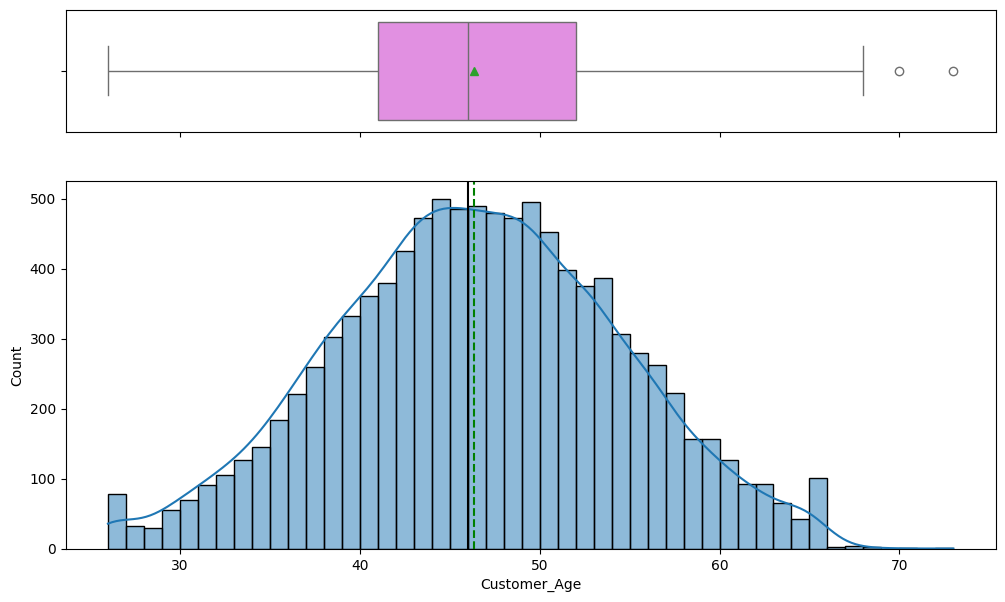

In [19]:
histogram_boxplot(data, "Customer_Age", kde=True)

`Months_on_book`

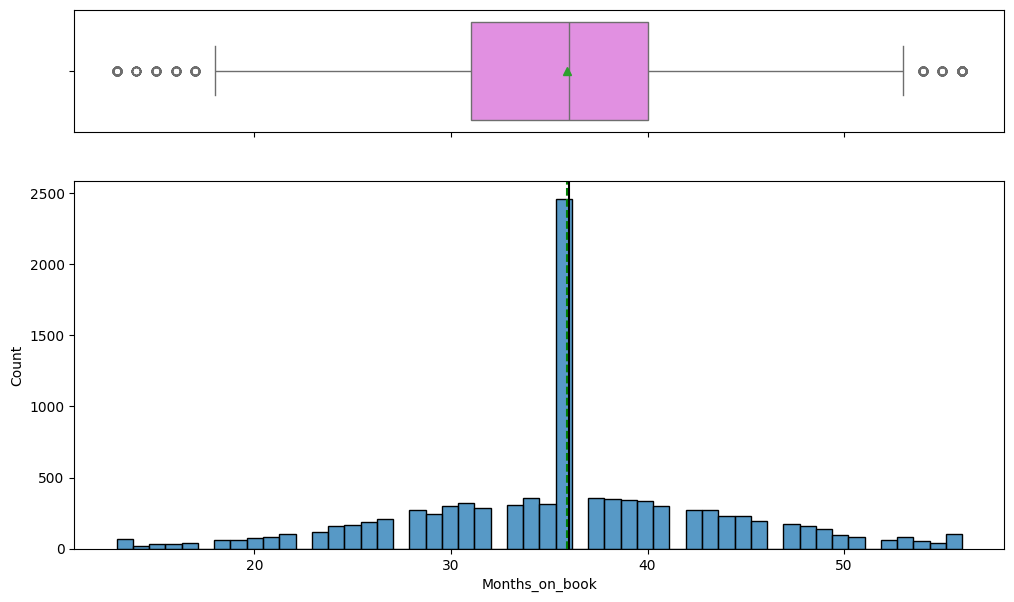

In [20]:
histogram_boxplot(data, 'Months_on_book')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Credit_Limit`

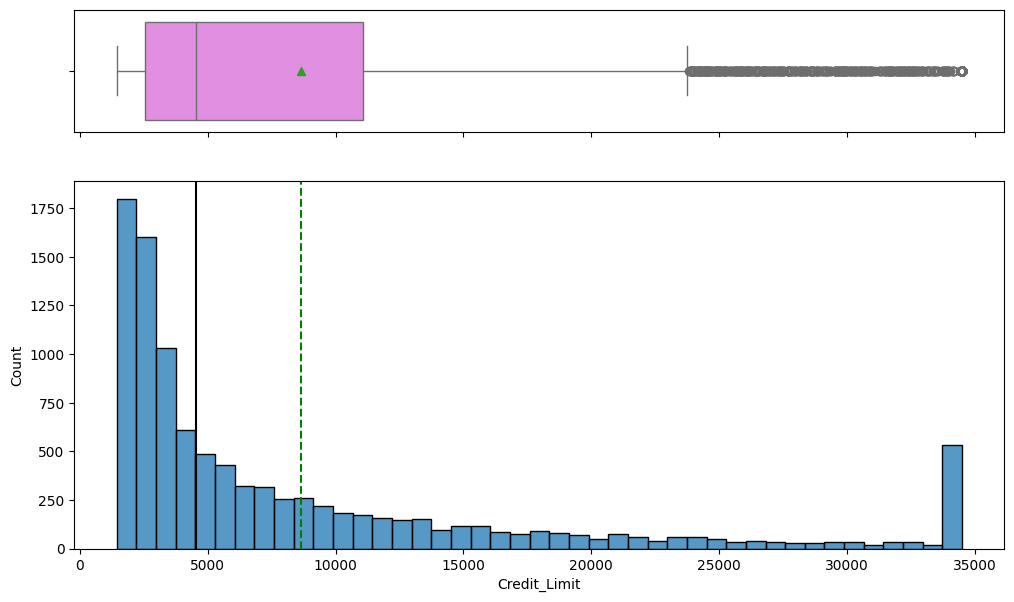

In [21]:
histogram_boxplot(data, 'Credit_Limit')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Revolving_Bal`

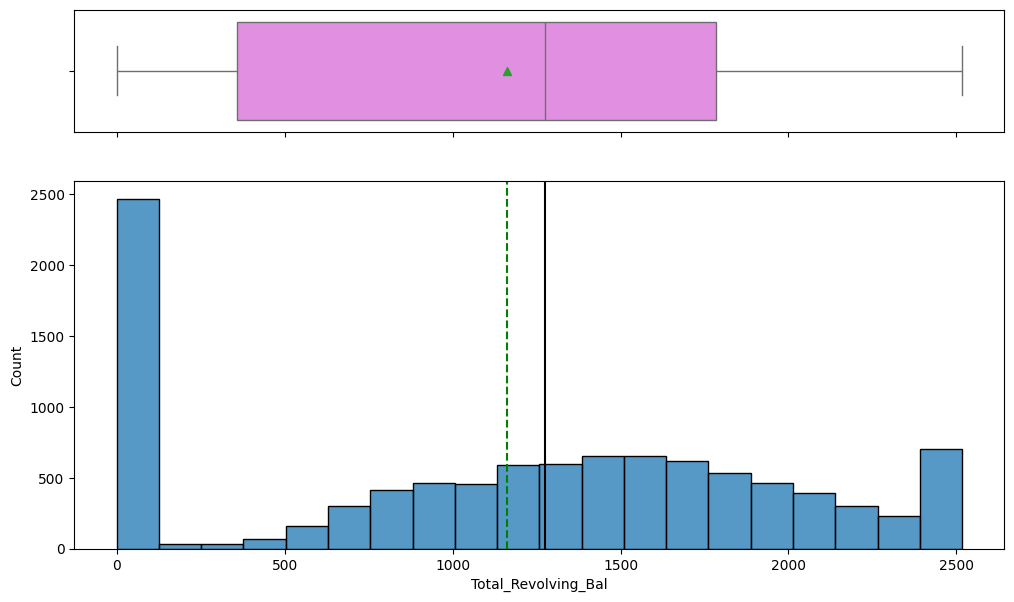

In [22]:
histogram_boxplot(data, 'Total_Revolving_Bal')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Avg_Open_To_Buy`

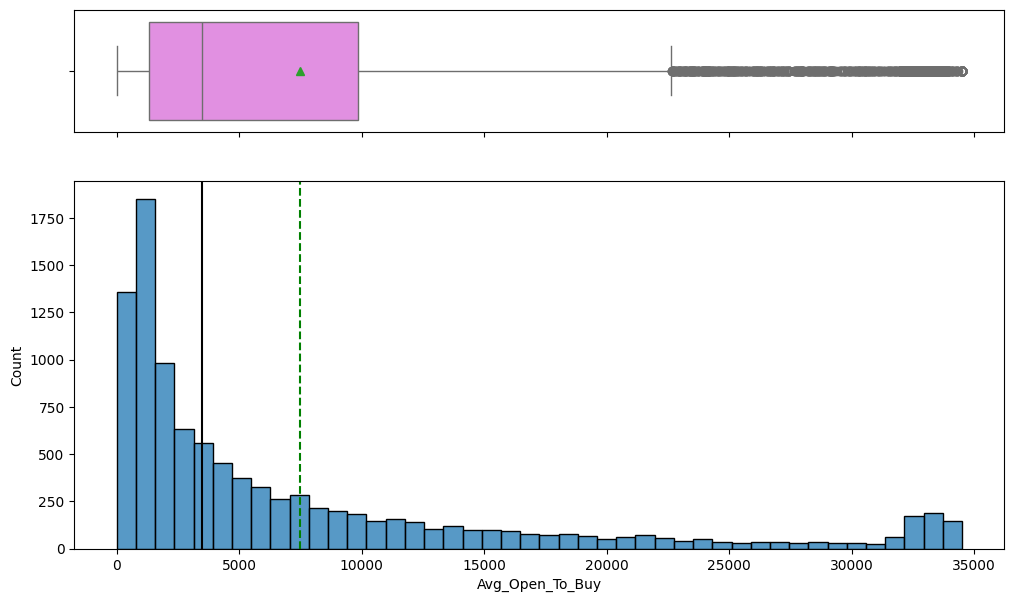

In [23]:
histogram_boxplot(data, 'Avg_Open_To_Buy')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Trans_Ct`

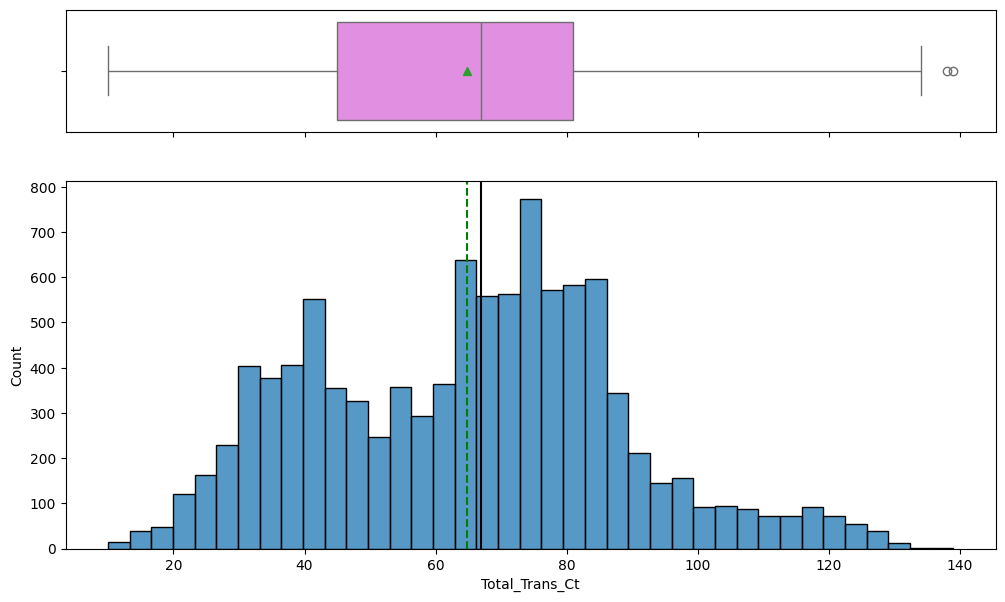

In [24]:
histogram_boxplot(data, 'Total_Trans_Ct')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Amt_Chng_Q4_Q1`

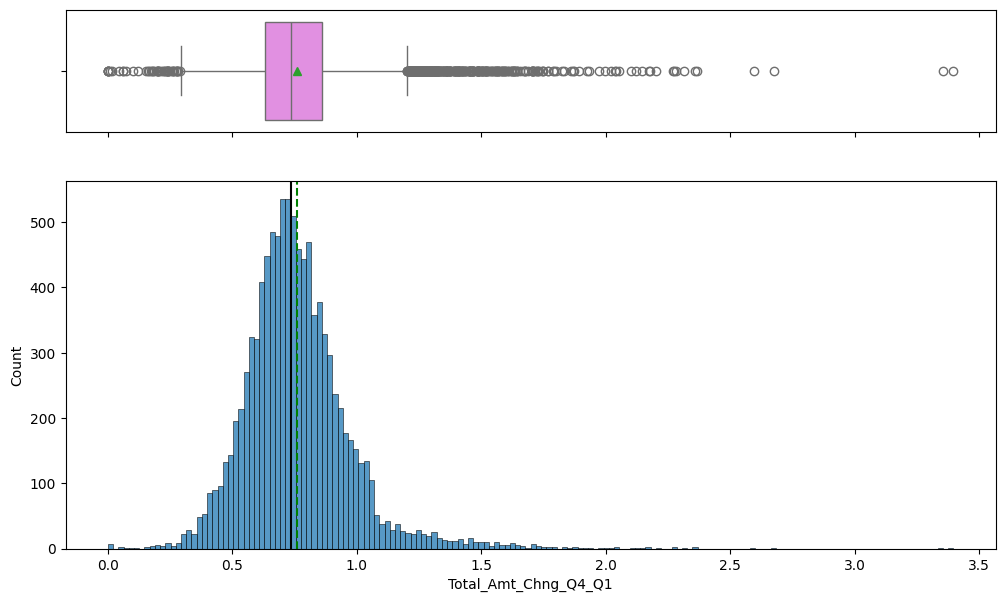

In [25]:
histogram_boxplot(data, 'Total_Amt_Chng_Q4_Q1')  ## Complete the code to create histogram_boxplot for 'New_Price'

**Let's see total transaction amount distributed**

`Total_Trans_Amt`

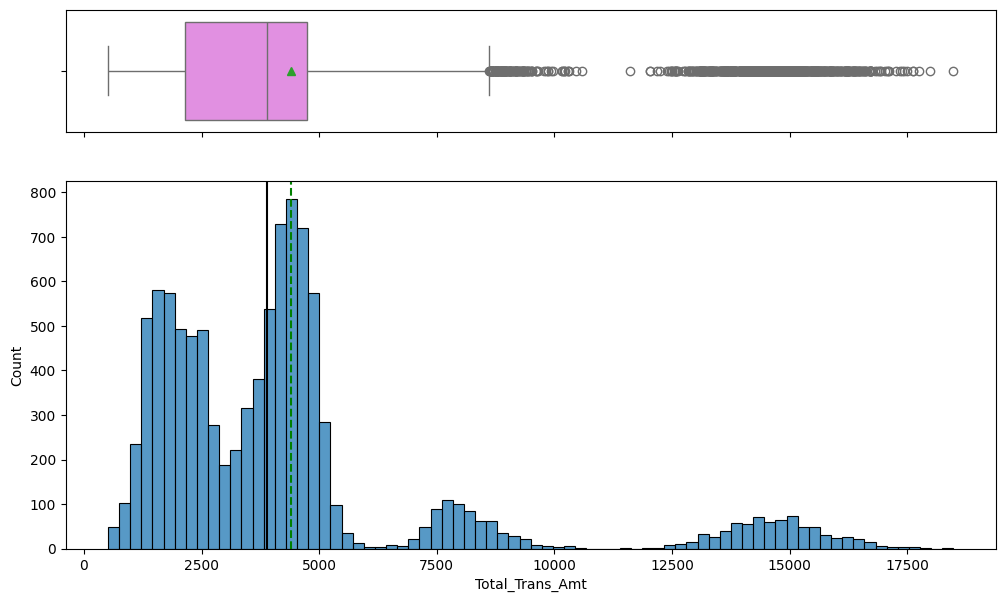

In [26]:
histogram_boxplot(data, 'Total_Trans_Amt')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Total_Ct_Chng_Q4_Q1`

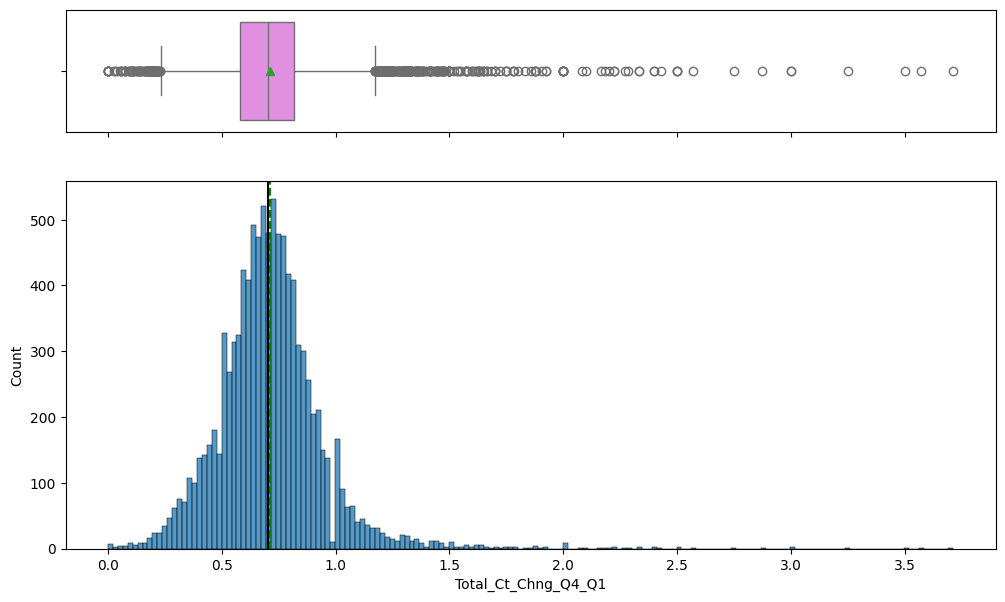

In [27]:
histogram_boxplot(data, 'Total_Ct_Chng_Q4_Q1')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Avg_Utilization_Ratio`

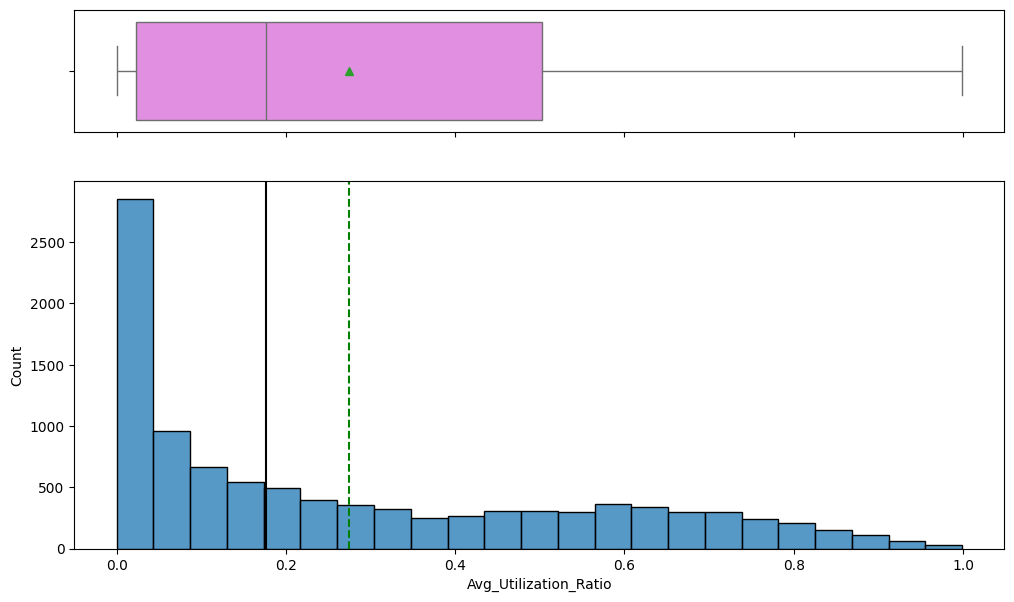

In [28]:
histogram_boxplot(data, 'Avg_Utilization_Ratio')  ## Complete the code to create histogram_boxplot for 'New_Price'

`Dependent_count`

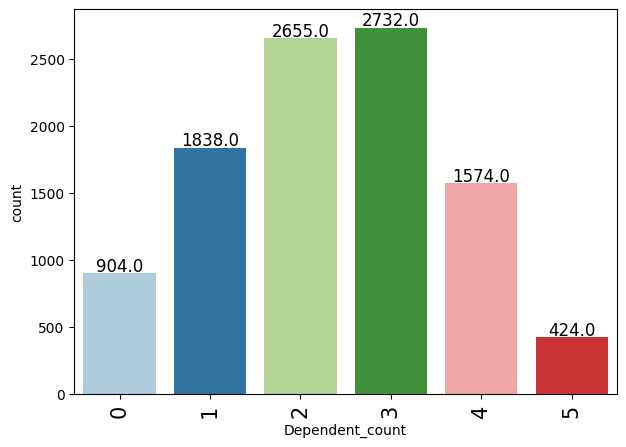

In [29]:
labeled_barplot(data, "Dependent_count")

`Total_Relationship_Count`

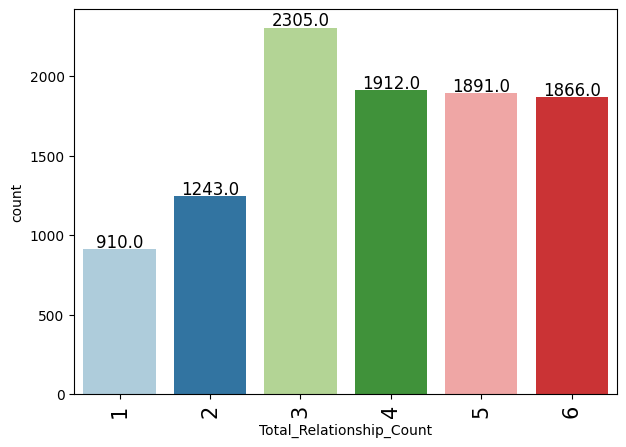

In [30]:
labeled_barplot(data, 'Total_Relationship_Count') ## Complete the code to create labeled_barplot for 'Total_Relationship_Count'

`Months_Inactive_12_mon`

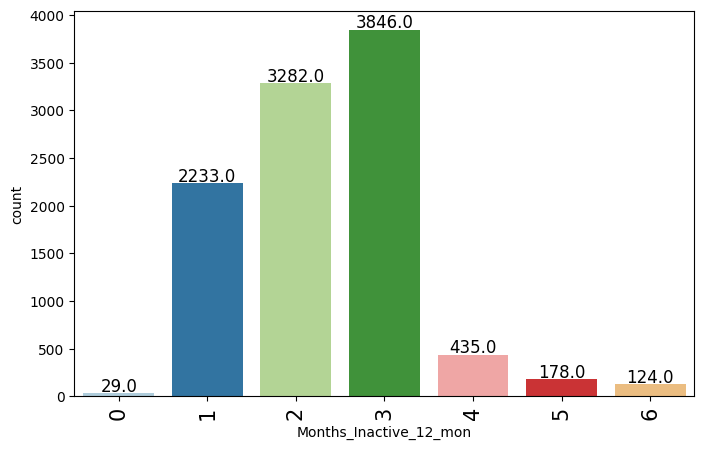

In [31]:
labeled_barplot(data, 'Months_Inactive_12_mon') ## Complete the code to create labeled_barplot for 'Months_Inactive_12_mon'

`Contacts_Count_12_mon`

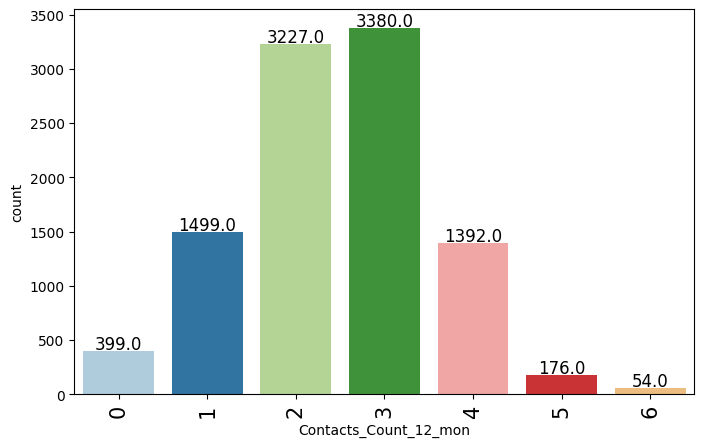

In [32]:
labeled_barplot(data, 'Contacts_Count_12_mon') ## Complete the code to create labeled_barplot for 'Contacts_Count_12_mon'

`Gender`

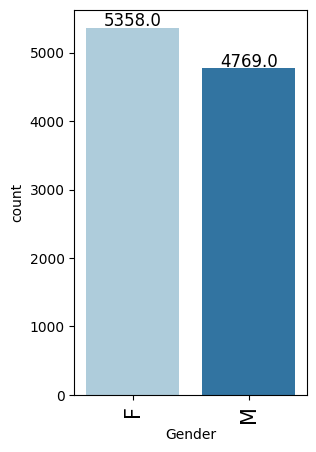

In [33]:
labeled_barplot(data, 'Gender') ## Complete the code to create labeled_barplot for 'Gender'

**Let's see the distribution of the level of education of customers**

`Education_Level`

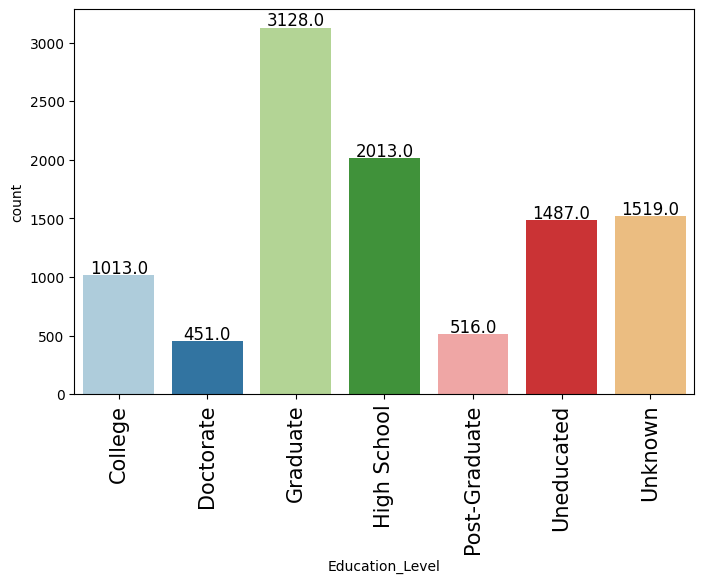

In [34]:
labeled_barplot(data, 'Education_Level') ## Complete the code to create labeled_barplot for 'Education_Level'

`Marital_Status`

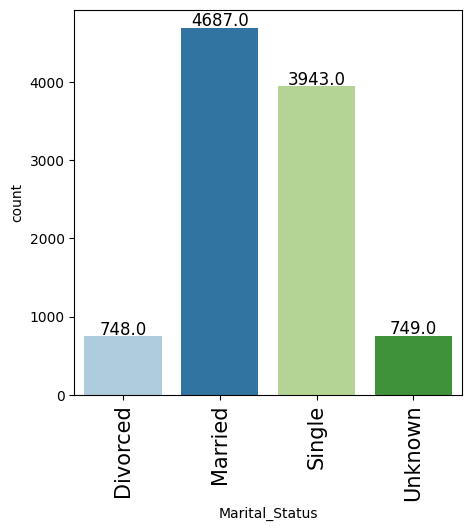

In [35]:
labeled_barplot(data, 'Marital_Status') ## Complete the code to create labeled_barplot for 'Marital_Status'

**Let's see the distribution of the level of income of customers**

`Income_Category`

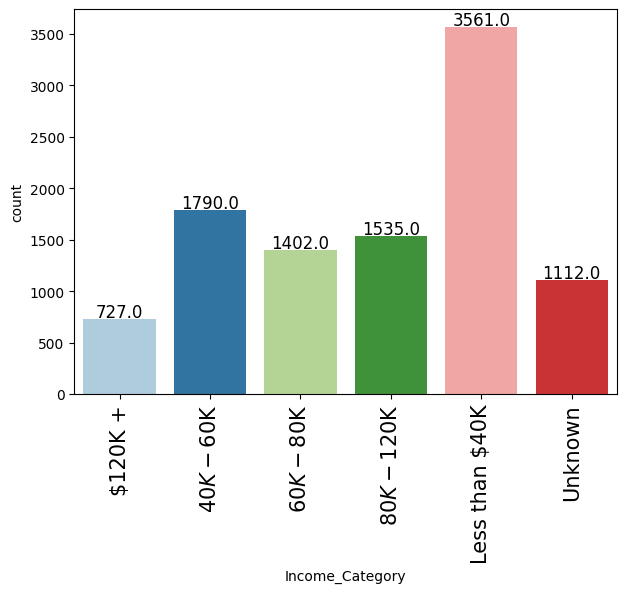

In [36]:
labeled_barplot(data, 'Income_Category') ## Complete the code to create labeled_barplot for 'Income_Category'

`Card_Category`

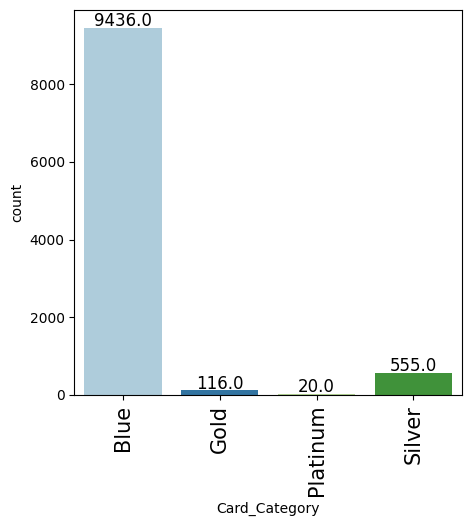

In [37]:
labeled_barplot(data, 'Card_Category') ## Complete the code to create labeled_barplot for 'Card_Category'

`Attrition_Flag`

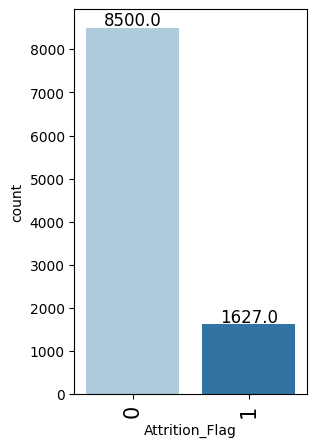

In [38]:
labeled_barplot(data, 'Attrition_Flag') ## Complete the code to create labeled_barplot for 'Attrition_Flag'

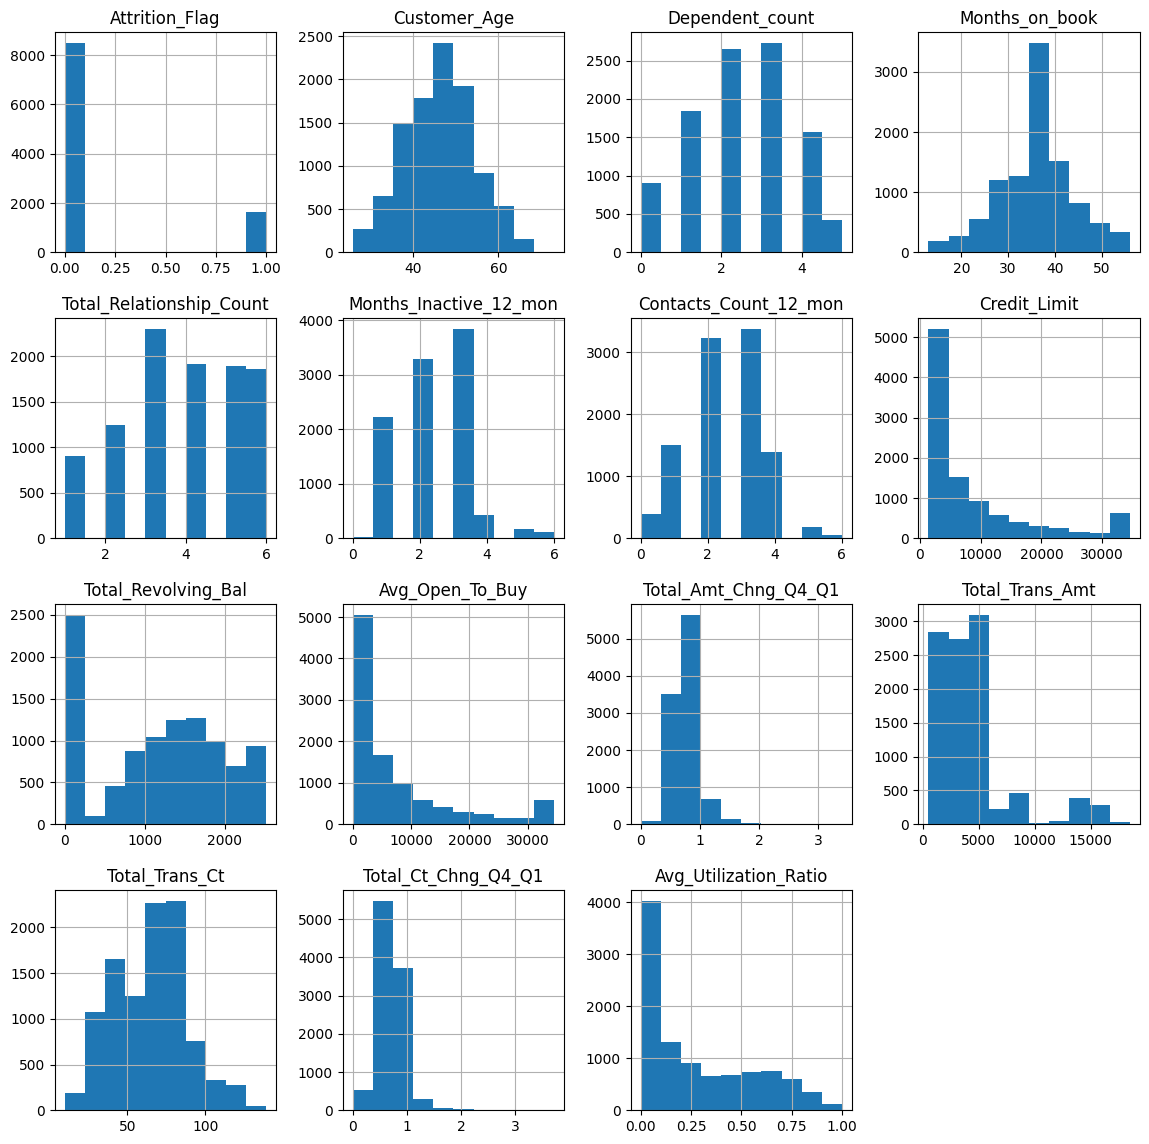

In [39]:
# creating histograms
data.hist(figsize=(14, 14))
plt.show()

### Bivariate Distributions

**Let's see the attributes that have a strong correlation with each other**

**Correlation Check**

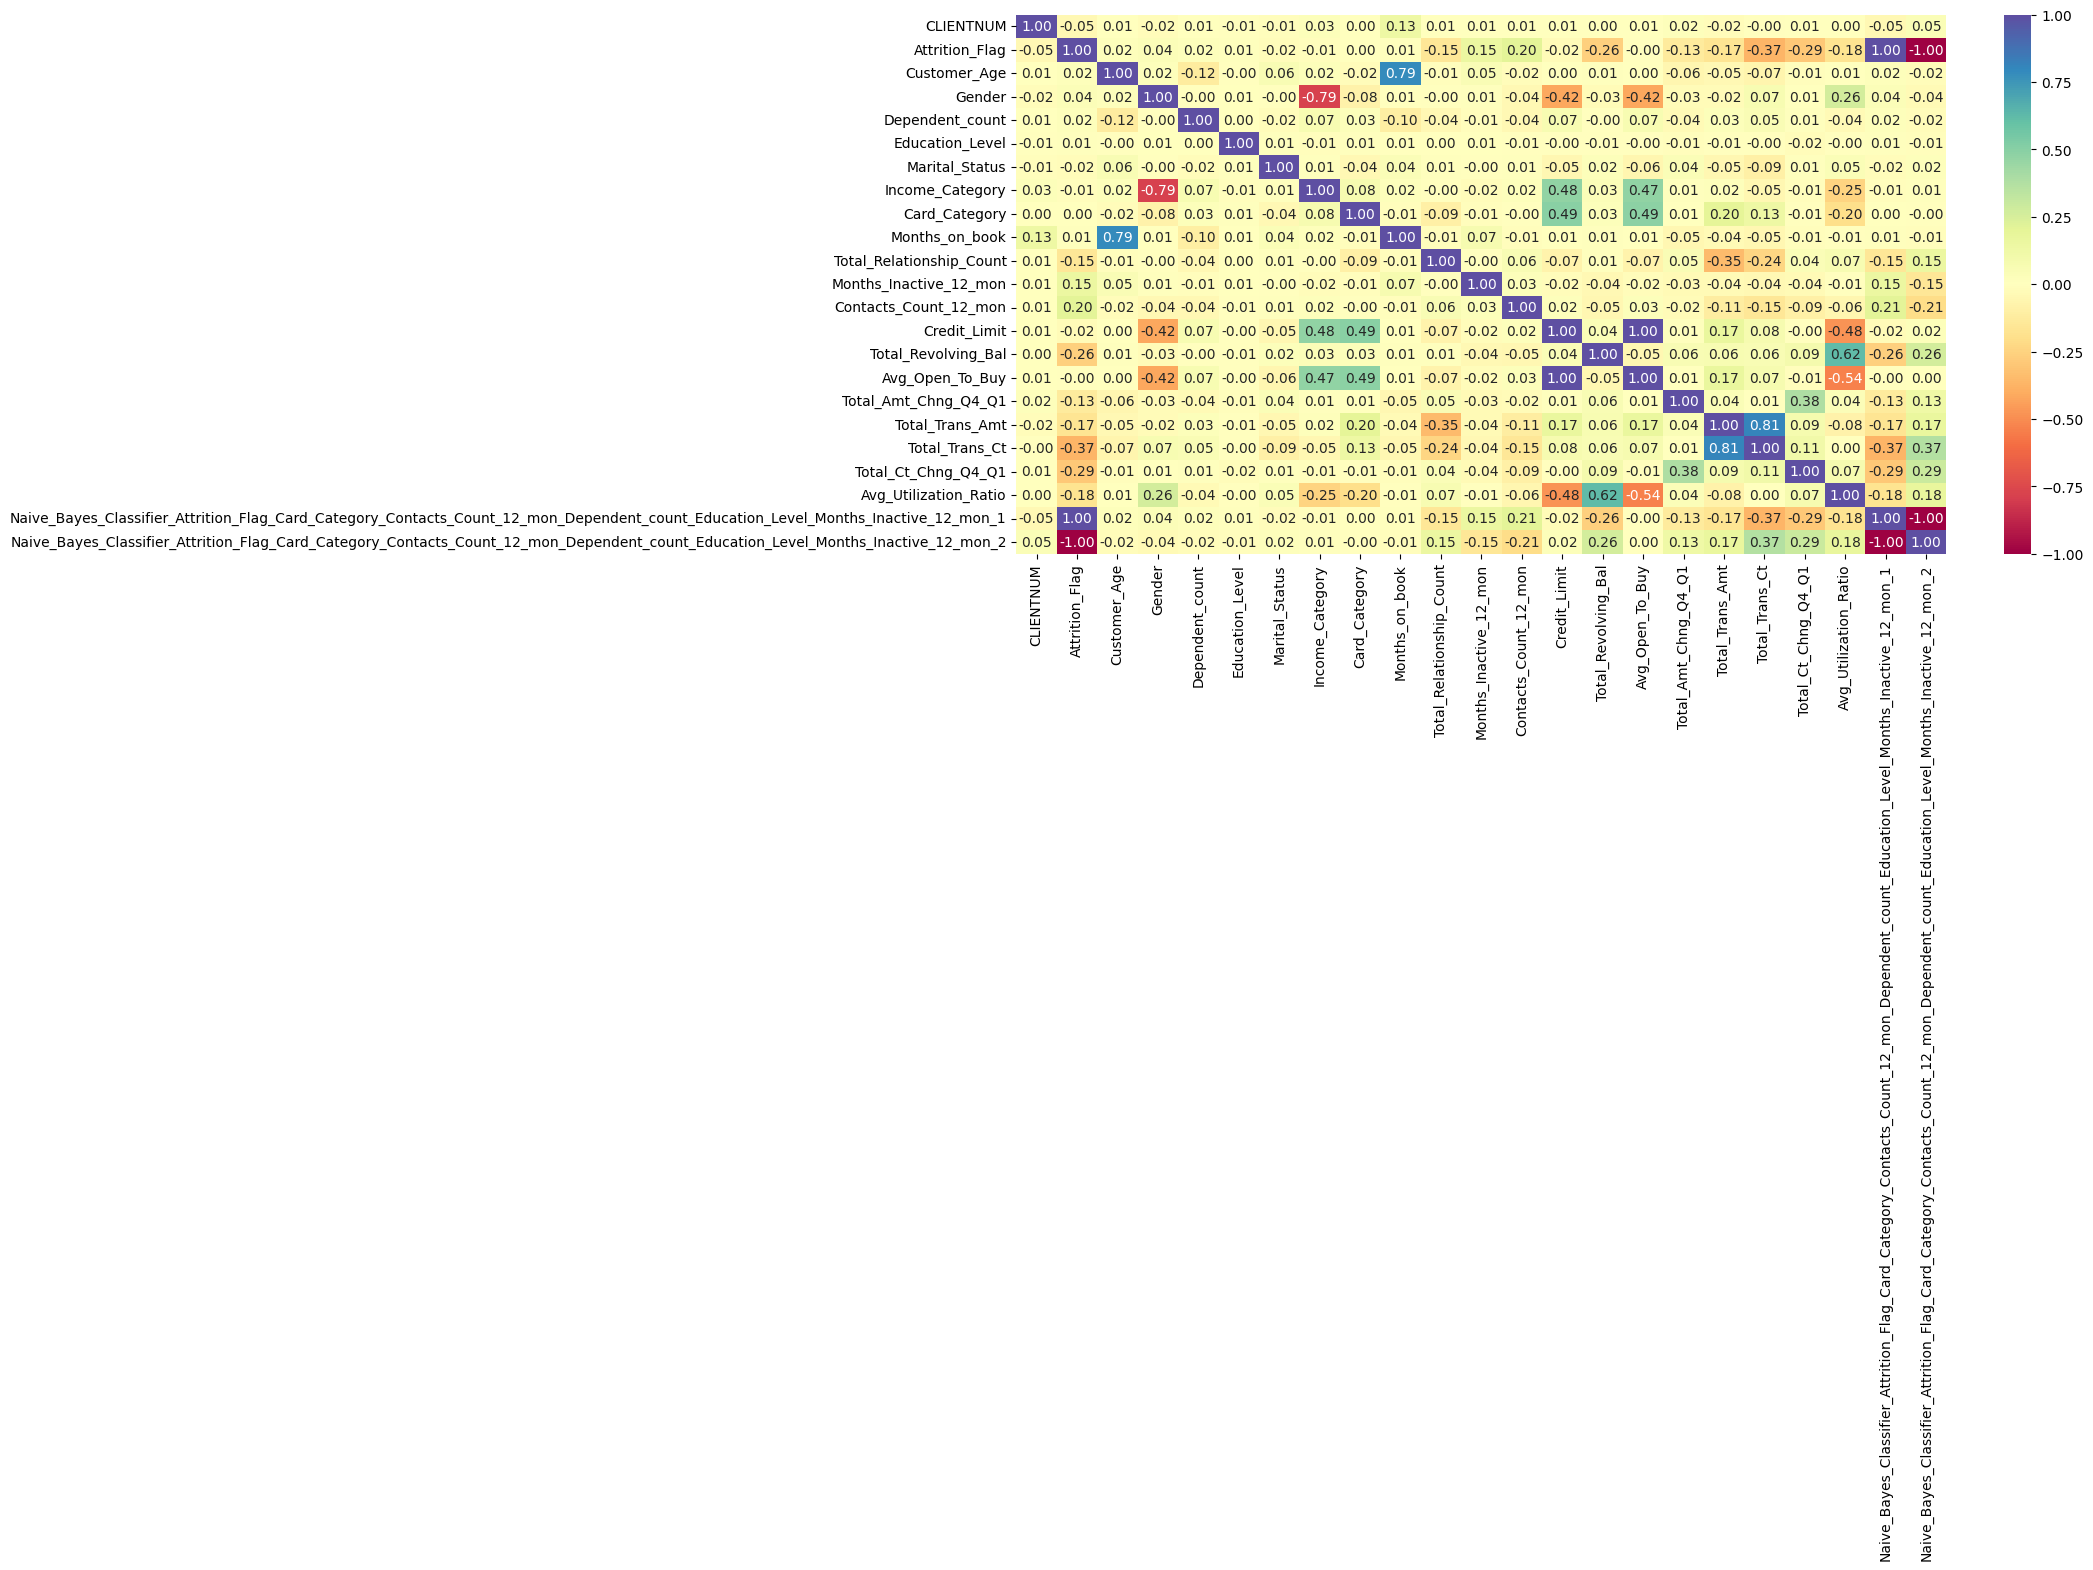

In [40]:
# Convert non-numerical columns to numerical representations if necessary
ReplaceStruct = {"Education_Level" : {'Uneducated': 0, 'High School': 1, 'College': 2, 'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': -1} ,
                 "Marital_Status" : {'Married': 2, 'Single': 1, 'Unknown': -1, 'Divorced': 0},
                 "Income_Category" : {'Less than $40K': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +': 4, 'Unknown': -1} ,
                 "Card_Category" : {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3},
                 "Attrition_Flag": {'Existing Customer': 0, 'Attrited Customer': 1},
                 "Gender": {'M': 0, 'F': 1}}
# Remove inplace=True to return the modified DataFrame
churn = churn.replace(ReplaceStruct)

# Now churn holds the modified DataFrame and you can proceed
plt.figure(figsize=(15, 7))
sns.heatmap(churn.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()



`Attrition_Flag vs Gender`

Attrition_Flag     0     1    All
Gender                           
All             8500  1627  10127
F               4428   930   5358
M               4072   697   4769
------------------------------------------------------------------------------------------------------------------------


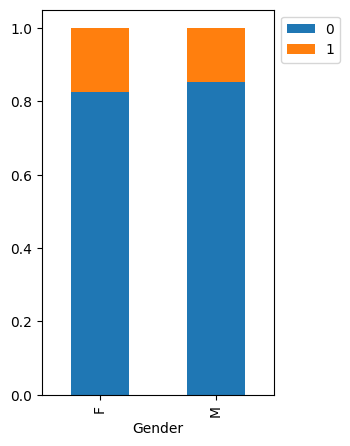

In [41]:
stacked_barplot(data, "Gender", "Attrition_Flag")

`Attrition_Flag vs Marital_Status`

Marital_Status  Divorced  Married  Single  Unknown    All
Attrition_Flag                                           
All                  748     4687    3943      749  10127
0                    627     3978    3275      620   8500
1                    121      709     668      129   1627
------------------------------------------------------------------------------------------------------------------------


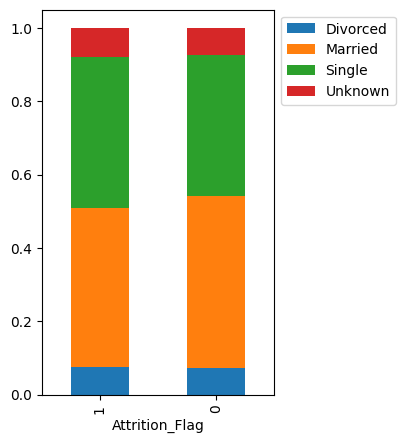

In [42]:
stacked_barplot(data,"Attrition_Flag", "Marital_Status") ## Complete the code to create distribution_plot for Attrition_Flag vs Marital_Status

`Attrition_Flag vs Education_Level`

Education_Level  College  Doctorate  Graduate  High School  Post-Graduate  \
Attrition_Flag                                                              
All                 1013        451      3128         2013            516   
0                    859        356      2641         1707            424   
1                    154         95       487          306             92   

Education_Level  Uneducated  Unknown    All  
Attrition_Flag                               
All                    1487     1519  10127  
0                      1250     1263   8500  
1                       237      256   1627  
------------------------------------------------------------------------------------------------------------------------


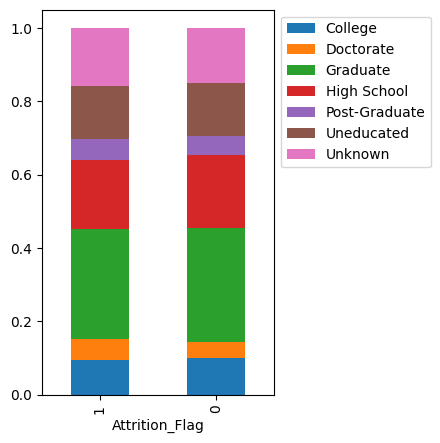

In [43]:
stacked_barplot(data,"Attrition_Flag", "Education_Level") ## Complete the code to create distribution_plot for Attrition_Flag vs Education_Level

`Attrition_Flag vs Income_Category`

Income_Category  $120K +  $40K - $60K  $60K - $80K  $80K - $120K  \
Attrition_Flag                                                     
All                  727         1790         1402          1535   
0                    601         1519         1213          1293   
1                    126          271          189           242   

Income_Category  Less than $40K  Unknown    All  
Attrition_Flag                                   
All                        3561     1112  10127  
0                          2949      925   8500  
1                           612      187   1627  
------------------------------------------------------------------------------------------------------------------------


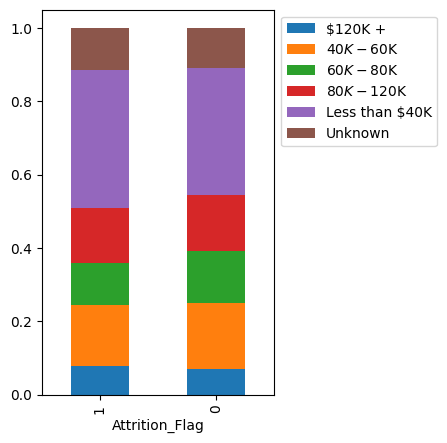

In [44]:
stacked_barplot(data,"Attrition_Flag", "Income_Category") ## Complete the code to create distribution_plot for Attrition_Flag vs Income_Category

`Attrition_Flag vs Contacts_Count_12_mon`

Contacts_Count_12_mon    0     1     2     3     4    5   6    All
Attrition_Flag                                                    
1                        7   108   403   681   315   59  54   1627
All                    399  1499  3227  3380  1392  176  54  10127
0                      392  1391  2824  2699  1077  117   0   8500
------------------------------------------------------------------------------------------------------------------------


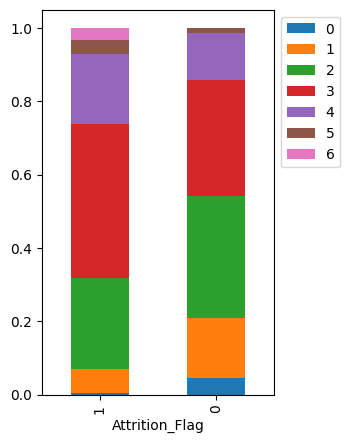

In [45]:
stacked_barplot(data,"Attrition_Flag", "Contacts_Count_12_mon") ## Complete the code to create distribution_plot for Attrition_Flag vs Income_Category

**Let's see the number of months a customer was inactive in the last 12 months (Months_Inactive_12_mon) vary by the customer's account status (Attrition_Flag)**

`Attrition_Flag vs Months_Inactive_12_mon`

Months_Inactive_12_mon   0     1     2     3    4    5    6    All
Attrition_Flag                                                    
All                     29  2233  3282  3846  435  178  124  10127
1                       15   100   505   826  130   32   19   1627
0                       14  2133  2777  3020  305  146  105   8500
------------------------------------------------------------------------------------------------------------------------


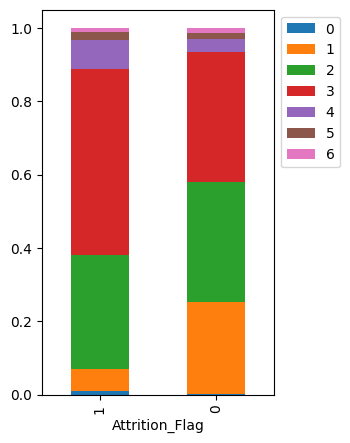

In [46]:
stacked_barplot(data,"Attrition_Flag", "Months_Inactive_12_mon") ## Complete the code to create distribution_plot for Attrition_Flag vs Months_Inactive_12_mon

`Attrition_Flag vs Total_Relationship_Count`

Total_Relationship_Count    1     2     3     4     5     6    All
Attrition_Flag                                                    
All                       910  1243  2305  1912  1891  1866  10127
0                         677   897  1905  1687  1664  1670   8500
1                         233   346   400   225   227   196   1627
------------------------------------------------------------------------------------------------------------------------


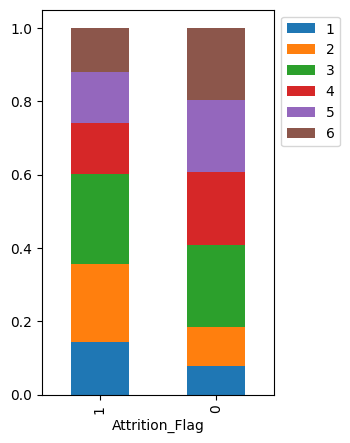

In [47]:
stacked_barplot(data,"Attrition_Flag","Total_Relationship_Count") ## Complete the code to create distribution_plot for Attrition_Flag vs Total_Relationship_Count

`Attrition_Flag vs Dependent_count`

Dependent_count    0     1     2     3     4    5    All
Attrition_Flag                                          
All              904  1838  2655  2732  1574  424  10127
0                769  1569  2238  2250  1314  360   8500
1                135   269   417   482   260   64   1627
------------------------------------------------------------------------------------------------------------------------


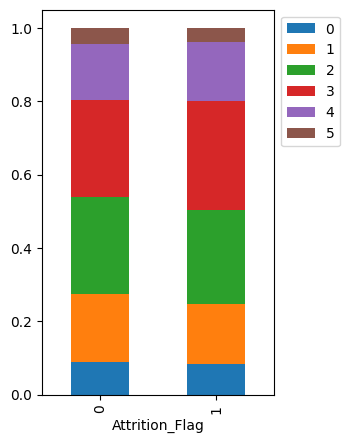

In [48]:
stacked_barplot(data,"Attrition_Flag", "Dependent_count") ## Complete the code to create distribution_plot for Attrition_Flag vs Dependent_count

`Total_Revolving_Bal` vs `Attrition_Flag`

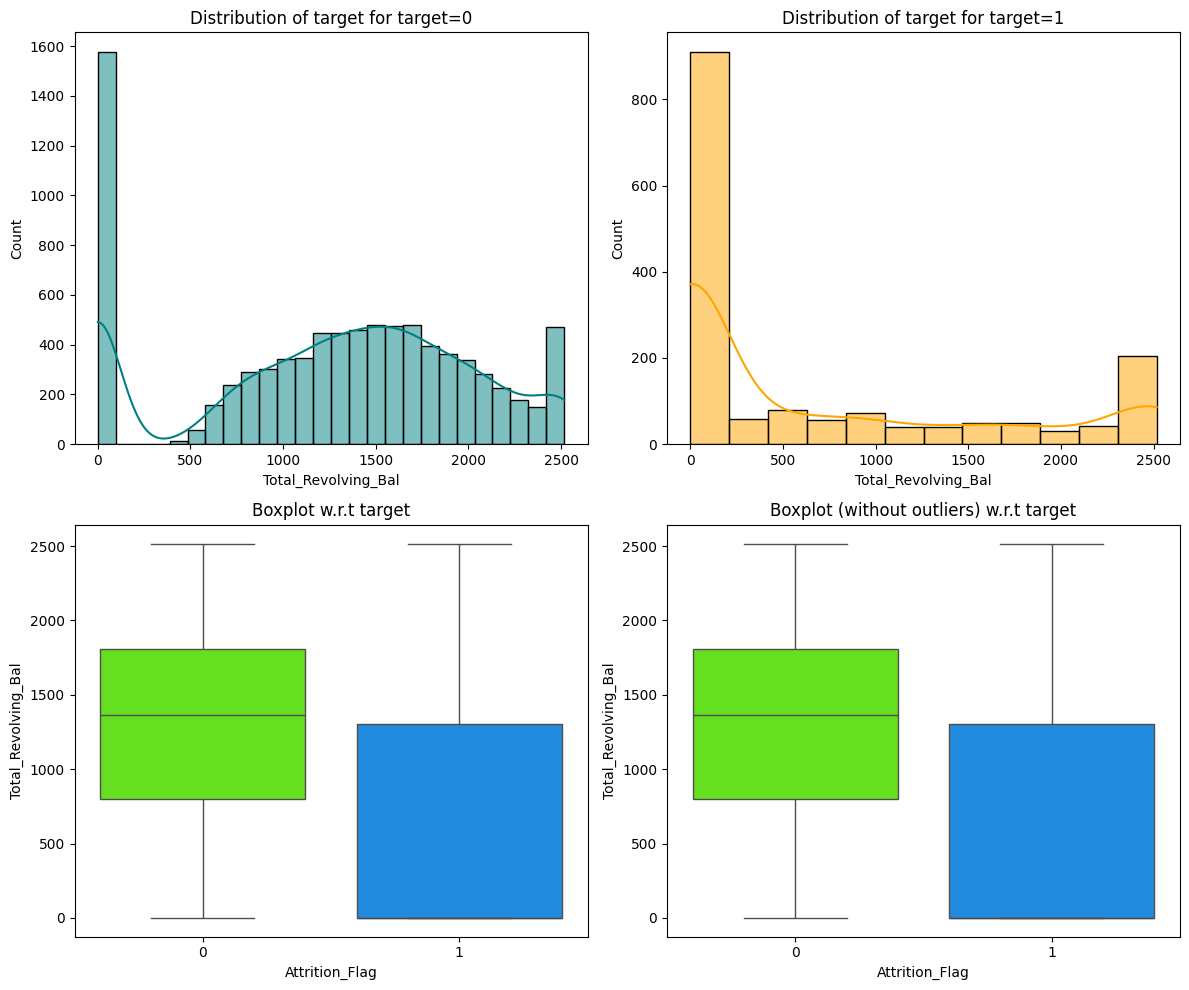

In [49]:
distribution_plot_wrt_target(data, "Total_Revolving_Bal", "Attrition_Flag")

`Attrition_Flag vs Credit_Limit`

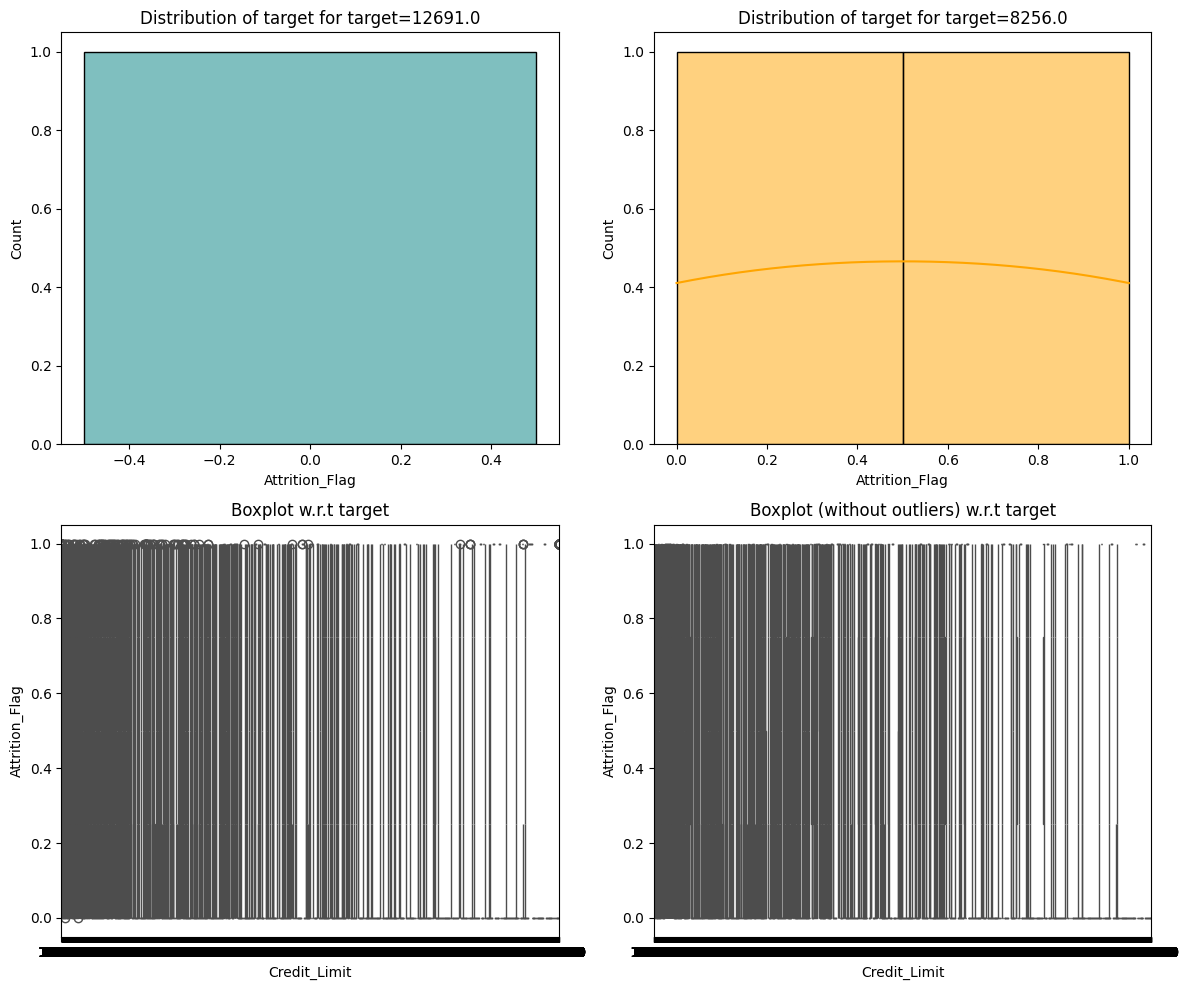

In [50]:
distribution_plot_wrt_target(data, "Attrition_Flag", "Credit_Limit") ## Complete the code to create distribution_plot for Attrition_Flag vs Credit_Limit

`Attrition_Flag vs Customer_Age`

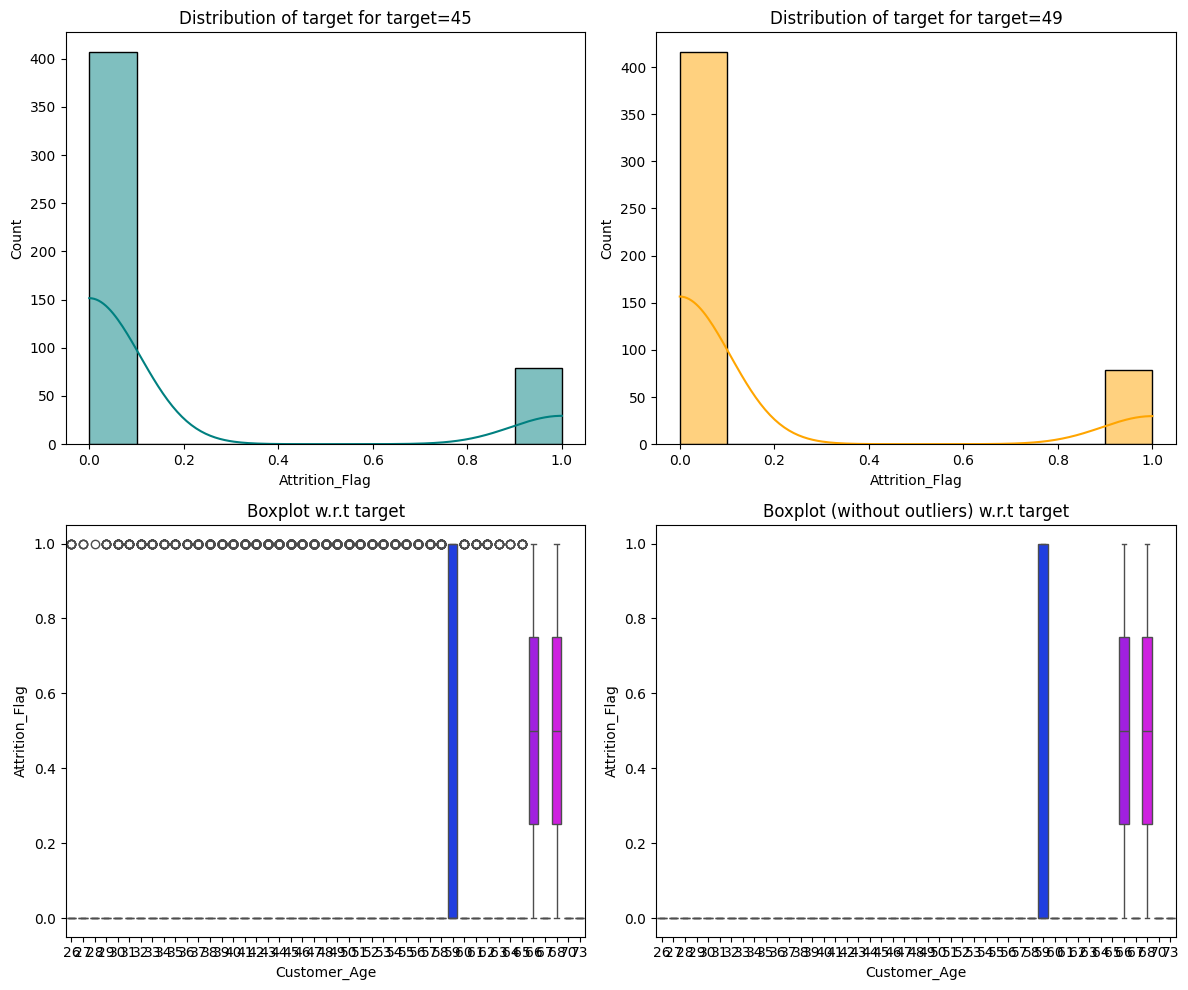

In [51]:
distribution_plot_wrt_target(data, "Attrition_Flag", "Customer_Age") ## Complete the code to create distribution_plot for Attrition_Flag vs Customer_Age

`Total_Trans_Ct` vs `Attrition_Flag`

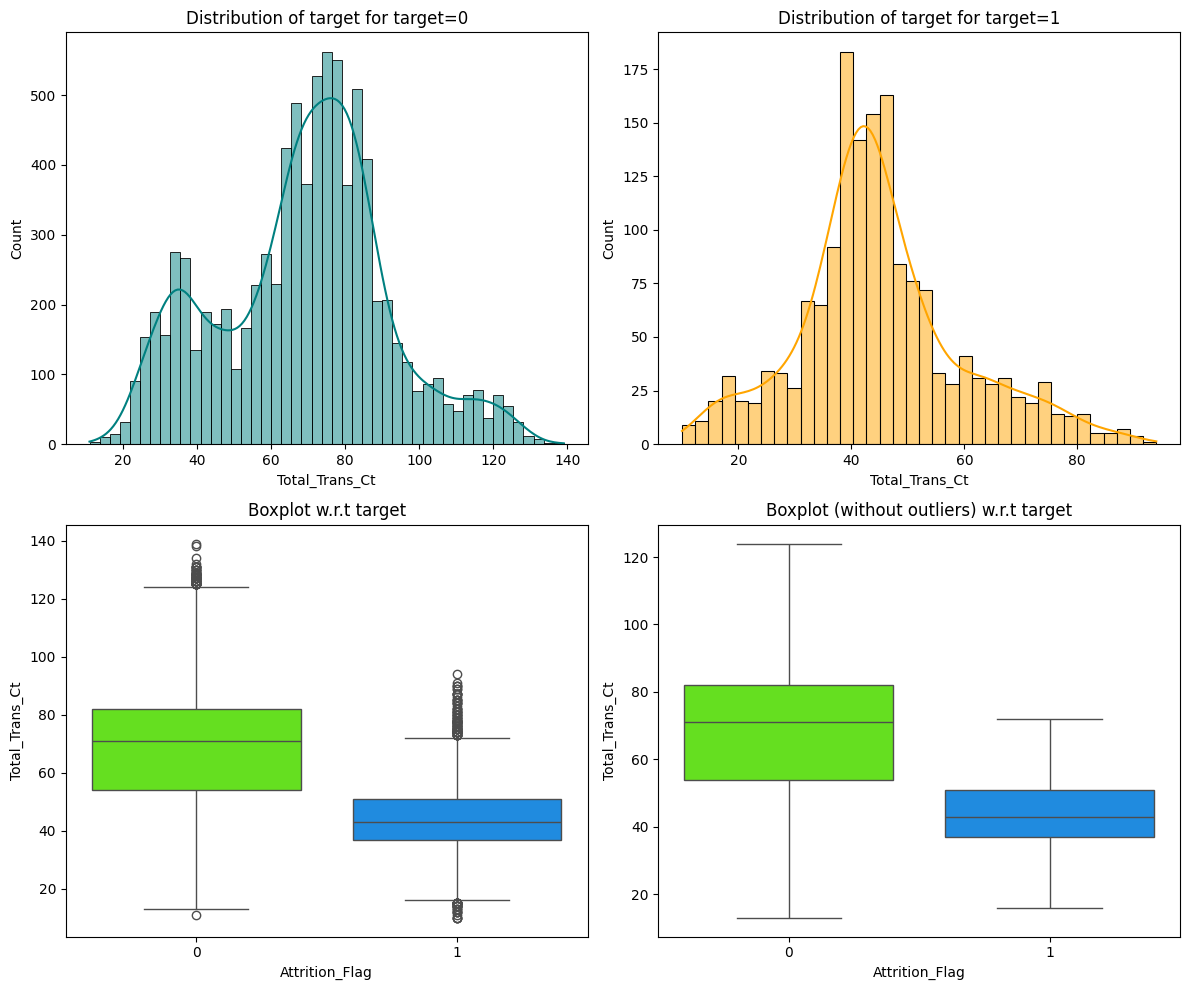

In [52]:
distribution_plot_wrt_target(data, "Total_Trans_Ct", "Attrition_Flag") ## Complete the code to create distribution_plot for Total_Trans_Ct vs Attrition_Flag

`Total_Trans_Amt` vs `Attrition_Flag`

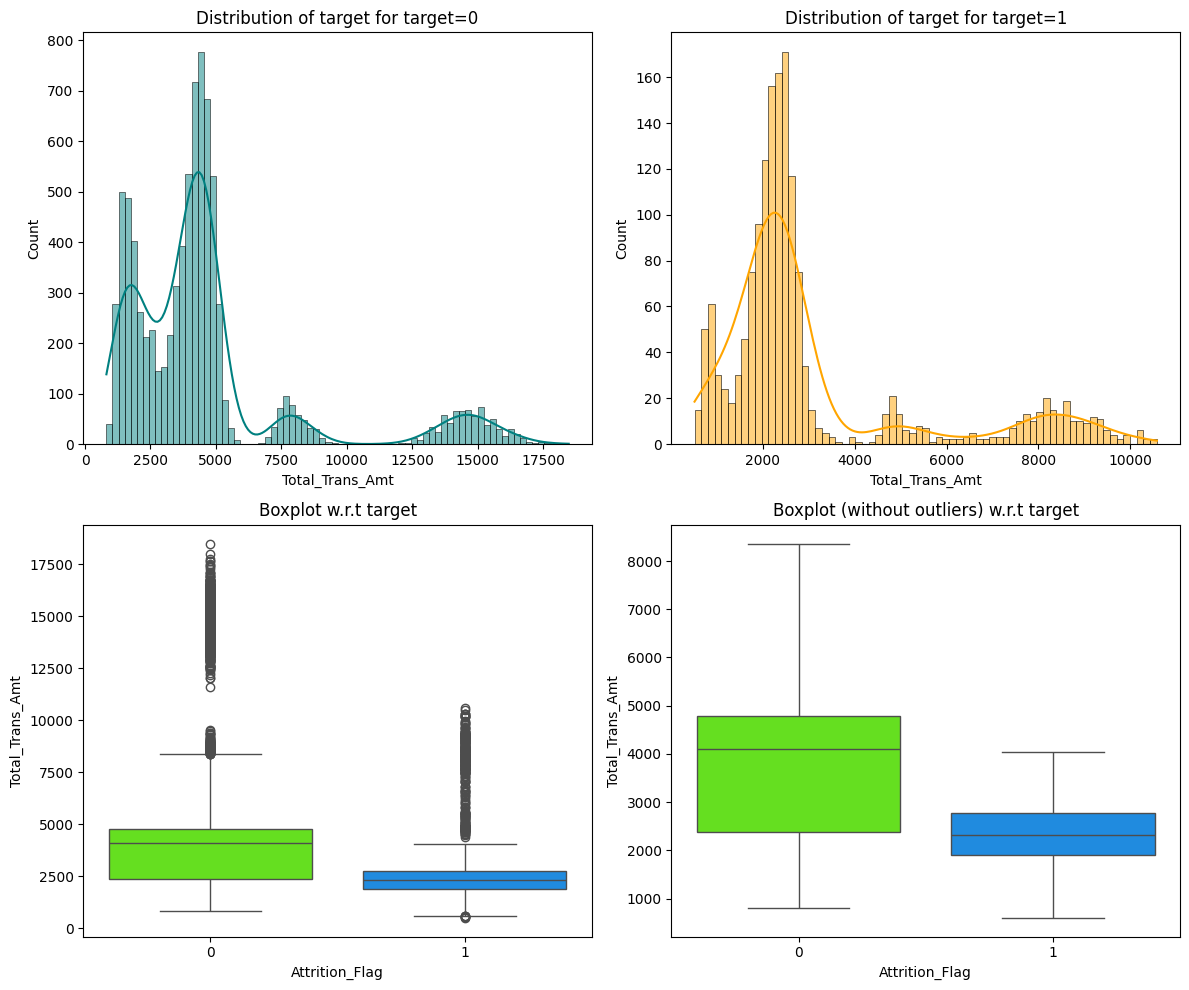

In [53]:
distribution_plot_wrt_target(data, "Total_Trans_Amt", "Attrition_Flag") ## Complete the code to create distribution_plot for Total_Trans_Amt vs Attrition_Flag

**Let's see the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer's account status (Attrition_Flag)**

`Total_Ct_Chng_Q4_Q1` vs `Attrition_Flag`

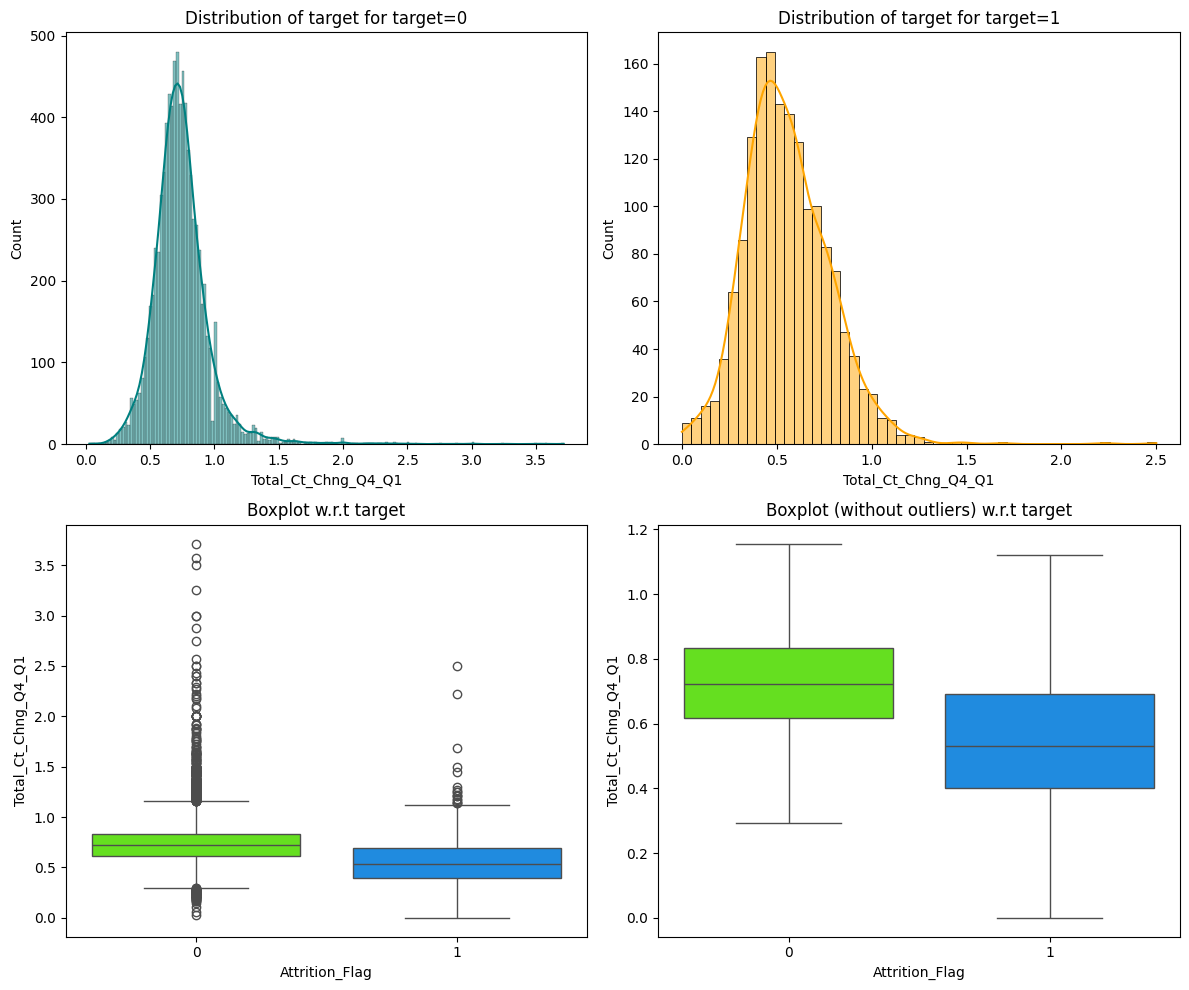

In [54]:
distribution_plot_wrt_target(data, "Total_Ct_Chng_Q4_Q1", "Attrition_Flag") ## Complete the code to create distribution_plot for Total_Ct_Chng_Q4_Q1 vs Attrition_Flag

`Avg_Utilization_Ratio` vs `Attrition_Flag`

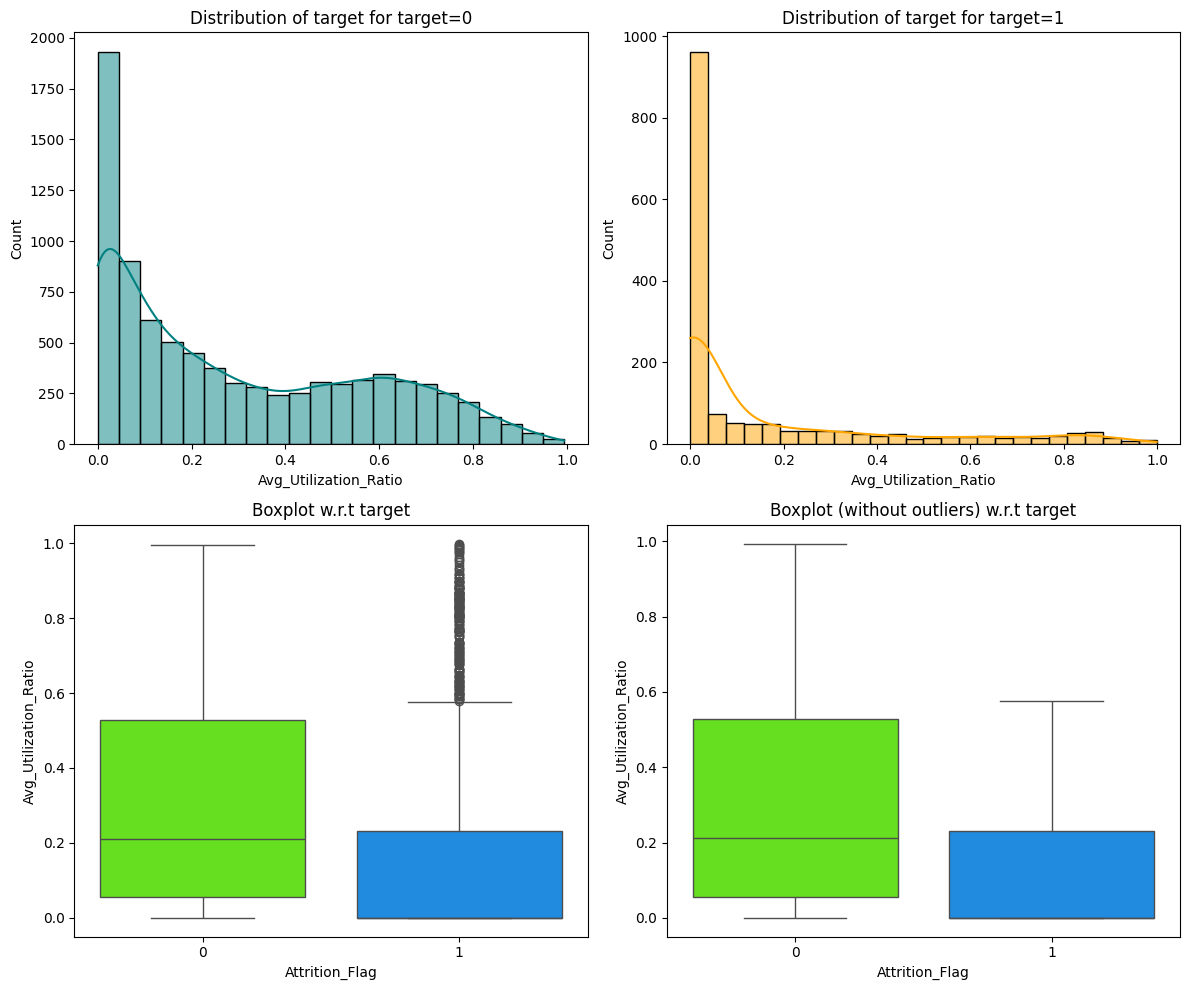

In [55]:
distribution_plot_wrt_target(data, "Avg_Utilization_Ratio", "Attrition_Flag") ## Complete the code to create distribution_plot for Avg_Utilization_Ratio vs Attrition_Flag


`Attrition_Flag vs Months_on_book`

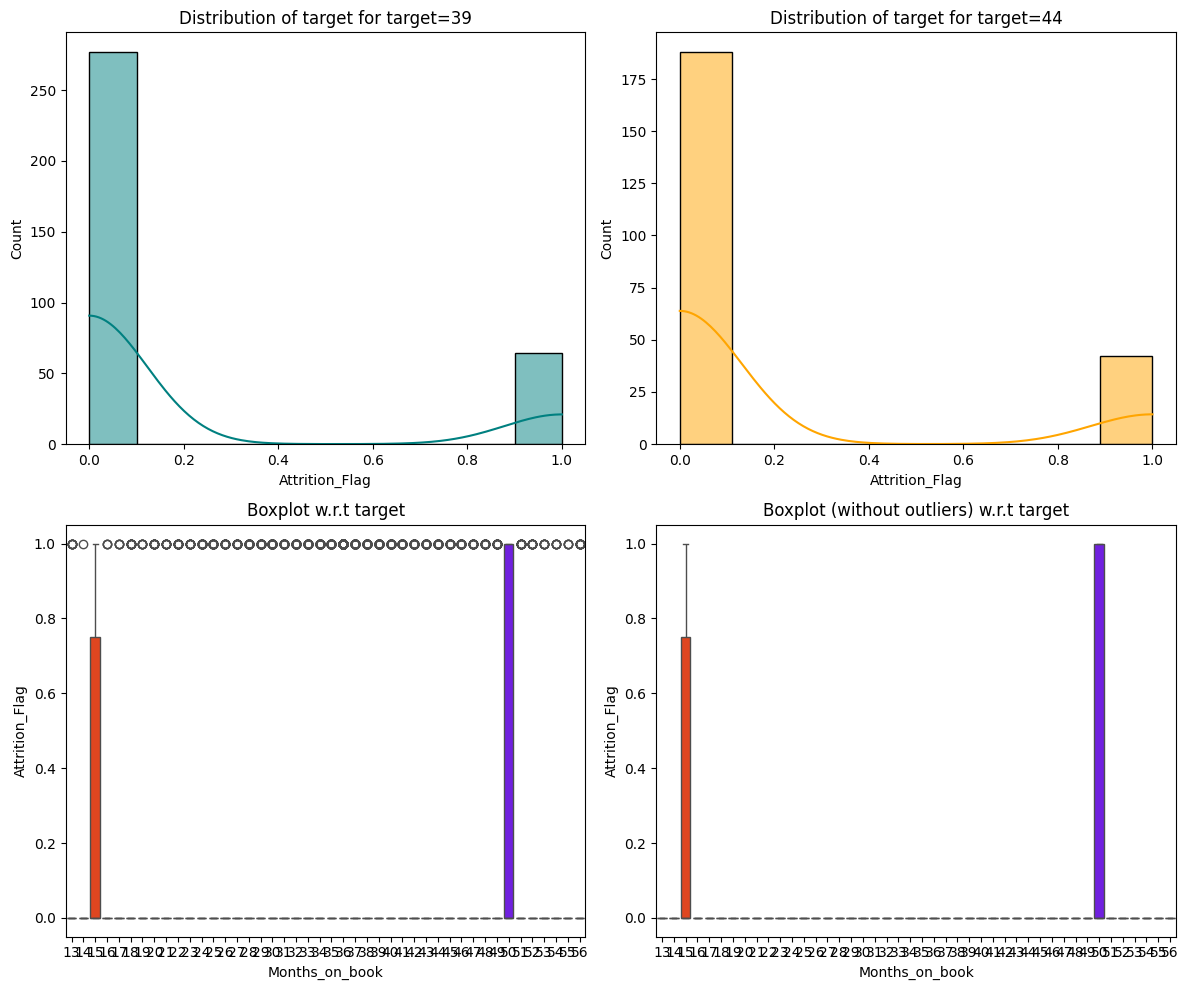

In [56]:
distribution_plot_wrt_target(data, "Attrition_Flag", "Months_on_book") ## Complete the code to create distribution_plot for Attrition_Flag vs Months_on_book

`Attrition_Flag vs Total_Revolving_Bal`

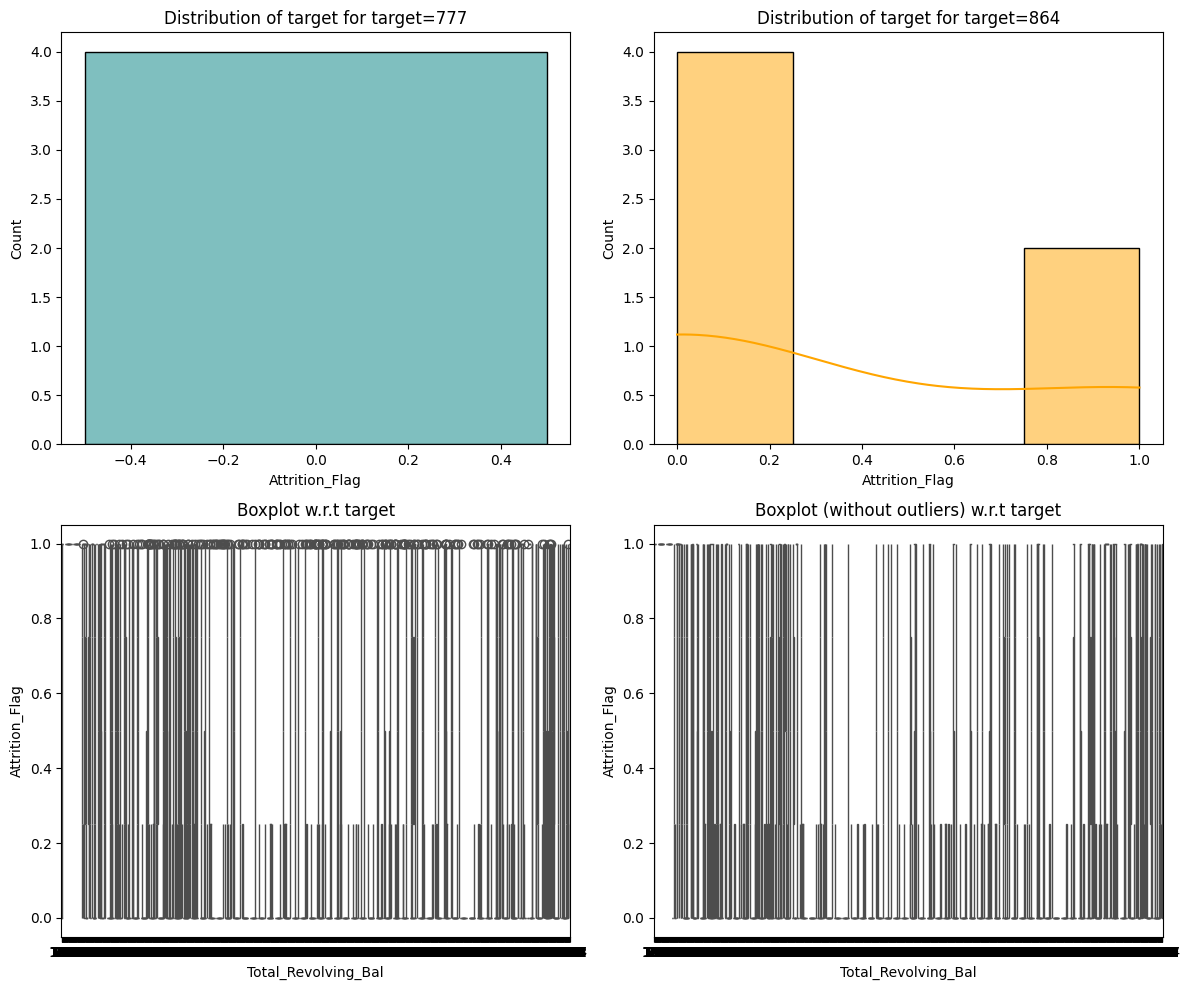

In [57]:
distribution_plot_wrt_target(data, "Attrition_Flag", "Total_Revolving_Bal") ## Complete the code to create distribution_plot for Attrition_Flag vs Total_Revolving_Bal

`Attrition_Flag vs Avg_Open_To_Buy`

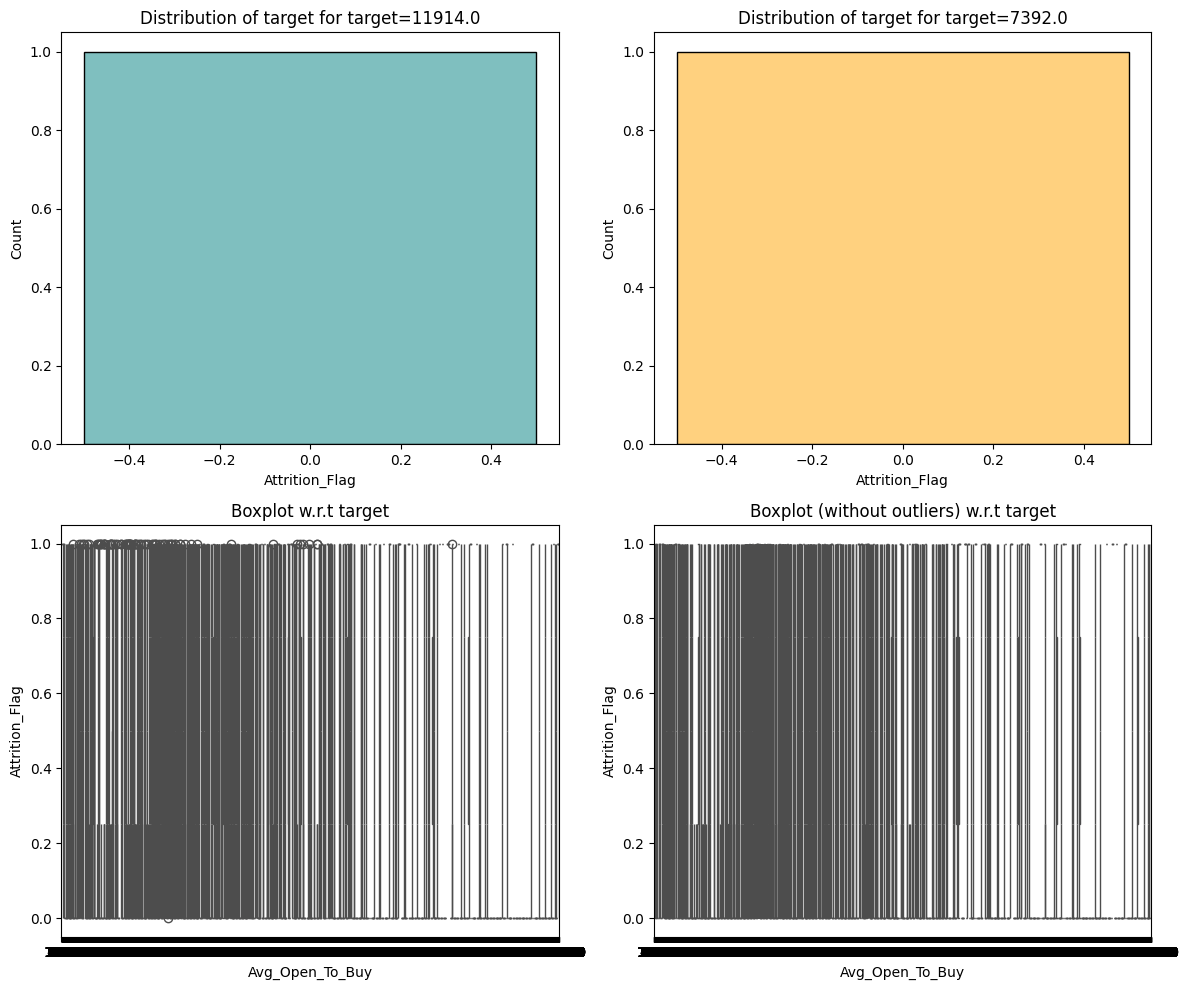

In [58]:
distribution_plot_wrt_target(data, "Attrition_Flag", "Avg_Open_To_Buy") ## Complete the code to create distribution_plot for Attrition_Flag vs Avg_Open_To_Buy

## Data Preprocessing

### Outlier Detection

In [59]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Calculate IQR and bounds for each numeric column
for column in numeric_data.columns:
    Q1 = numeric_data[column].quantile(0.25)
    Q3 = numeric_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

In [60]:
# checking the % outliers
((data.select_dtypes(include=["float64", "int64"]) < lower) | (data.select_dtypes(include=["float64", "int64"]) > upper)).sum() / len(data) * 100

Attrition_Flag               0.000
Customer_Age               100.000
Dependent_count             72.924
Months_on_book             100.000
Total_Relationship_Count    91.014
Months_Inactive_12_mon      77.664
Contacts_Count_12_mon       81.258
Credit_Limit               100.000
Total_Revolving_Bal         75.610
Avg_Open_To_Buy            100.000
Total_Amt_Chng_Q4_Q1         3.229
Total_Trans_Amt            100.000
Total_Trans_Ct             100.000
Total_Ct_Chng_Q4_Q1          2.340
Avg_Utilization_Ratio        0.000
dtype: float64

### Train-Test Split

In [61]:
# creating the copy of the dataframe
data1 = data.copy()

In [62]:
# Replace anomalous and "Unknown" values with NaN for proper imputation
for col in ["Education_Level", "Marital_Status", "Income_Category"]:
    data1[col].replace("Unknown", np.nan, inplace=True)

# Also fix Income_Category anomalous numeric zeros
data1["Income_Category"].replace([0, 'NaN'], np.nan, inplace=True)

print("Missing values after replacing Unknown with NaN:")
print(data1[["Education_Level", "Marital_Status", "Income_Category"]].isna().sum())

Missing values after replacing Unknown with NaN:
Education_Level    1519
Marital_Status      749
Income_Category    1112
dtype: int64


In [63]:
data1.isna().sum()

Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category             1112
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

In [64]:
# creating an instace of the imputer to be used
imputer = SimpleImputer(strategy="most_frequent")

In [65]:
# Dividing train data into X and y

X = data1.drop(["Attrition_Flag"], axis=1)
y = data1["Attrition_Flag"]

In [66]:
# Splitting data into training, validation, and test sets
# 80% train | 15% val | 5% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fixed: original code had X_test and X_val names swapped
# test_size=0.25 of the 20% temp -> 5% test, 15% val
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Shapes  -> Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Churn rate Train:", round(y_train.mean(), 3),
      "| Val:", round(y_val.mean(), 3),
      "| Test:", round(y_test.mean(), 3))

Shapes  -> Train: (8101, 19) | Val: (1519, 19) | Test: (507, 19)
Churn rate Train: 0.16 | Val: 0.167 | Test: 0.146


### Missing value imputation

In [67]:
reqd_col_for_impute = ["Education_Level", "Marital_Status", "Income_Category"]

In [68]:
# Fit and transform the train data
X_train[reqd_col_for_impute] = imputer.fit_transform(X_train[reqd_col_for_impute])

# Transform the validation data
X_val[reqd_col_for_impute]  =  imputer.transform(X_val[reqd_col_for_impute]) ## Complete the code to impute missing values in X_val

# Transform the test data
X_test[reqd_col_for_impute] = imputer.transform(X_test[reqd_col_for_impute]) ## Complete the code to impute missing values in X_test

In [69]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
------------------------------
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal       

In [70]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

Gender
F    4279
M    3822
Name: count, dtype: int64
******************************
Education_Level
Graduate         3733
High School      1619
Uneducated       1171
College           816
Post-Graduate     407
Doctorate         355
Name: count, dtype: int64
******************************
Marital_Status
Married     4346
Single      3144
Divorced     611
Name: count, dtype: int64
******************************
Income_Category
Less than $40K    3701
$40K - $60K       1453
$80K - $120K      1237
$60K - $80K       1122
$120K +            588
Name: count, dtype: int64
******************************
Card_Category
Blue        7557
Silver       436
Gold          93
Platinum      15
Name: count, dtype: int64
******************************


In [71]:
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

Gender
F    813
M    706
Name: count, dtype: int64
******************************
Education_Level
Graduate         677
High School      300
Uneducated       232
College          148
Post-Graduate     90
Doctorate         72
Name: count, dtype: int64
******************************
Marital_Status
Married     818
Single      606
Divorced     95
Name: count, dtype: int64
******************************
Income_Category
Less than $40K    736
$40K - $60K       249
$80K - $120K      227
$60K - $80K       206
$120K +           101
Name: count, dtype: int64
******************************
Card_Category
Blue        1414
Silver        82
Gold          20
Platinum       3
Name: count, dtype: int64
******************************


In [72]:
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

Gender
F    4279
M    3822
Name: count, dtype: int64
******************************
Education_Level
Graduate         3733
High School      1619
Uneducated       1171
College           816
Post-Graduate     407
Doctorate         355
Name: count, dtype: int64
******************************
Marital_Status
Married     4346
Single      3144
Divorced     611
Name: count, dtype: int64
******************************
Income_Category
Less than $40K    3701
$40K - $60K       1453
$80K - $120K      1237
$60K - $80K       1122
$120K +            588
Name: count, dtype: int64
******************************
Card_Category
Blue        7557
Silver       436
Gold          93
Platinum      15
Name: count, dtype: int64
******************************


### Encoding categorical variables

In [73]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)  ## Complete the code to impute missing values in X_val
X_test = pd.get_dummies(X_test, drop_first=True) ## Complete the code to impute missing values in X_val
print(X_train.shape, X_val.shape, X_test.shape)

(8101, 29) (1519, 29) (507, 29)


### Handle Class Imbalance with SMOTE

In [74]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train.value_counts())
print(f"Churn rate: {y_train.mean():.3f}\n")

sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
import pandas as pd
print(pd.Series(y_train_res).value_counts())
print(f"Churn rate after SMOTE: {pd.Series(y_train_res).mean():.3f}")
print("X_train_res shape:", X_train_res.shape)

Class distribution before SMOTE:
Attrition_Flag
0    6801
1    1300
Name: count, dtype: int64
Churn rate: 0.160

Class distribution after SMOTE:
Attrition_Flag
0    6801
1    6801
Name: count, dtype: int64
Churn rate after SMOTE: 0.500
X_train_res shape: (13602, 29)


* After encoding there are 29 columns.

In [75]:
# check the top 5 rows from the train dataset
X_train.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Marital_Status_Married,Marital_Status_Single,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
9066,54,1,36,1,3,3,3723.000,1728,1995.000,0.595,8554,99,0.678,0.464,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False
5814,58,4,48,1,4,3,5396.000,1803,3593.000,0.493,2107,39,0.393,0.334,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False
792,45,4,36,6,1,3,15987.000,1648,14339.000,0.732,1436,36,1.250,0.103,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False
1791,34,2,36,4,3,4,3625.000,2517,1108.000,1.158,2616,46,1.300,0.694,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False
5011,49,2,39,5,3,4,2720.000,1926,794.000,0.602,3806,61,0.794,0.708,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False


## Building Model

### Model Evaluation Criterion

The bank's primary concern is identifying customers who are **about to leave** (Attrited = 1). Missing a churner (False Negative) is more costly than a false alarm. Therefore **Recall** is the primary metric, with ROC-AUC as the secondary.

In [76]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

### Scale Features

In [77]:
# StandardScaler: fit only on training data, transform val/test
# (uses X_train_res = SMOTE-resampled training set)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Scaled shapes -> Train:", X_train_sc.shape,
      "| Val:", X_val_sc.shape,
      "| Test:", X_test_sc.shape)

Scaled shapes -> Train: (13602, 29) | Val: (1519, 29) | Test: (507, 29)


### Define & Train Neural Network (MLP)

In [78]:
# Neural Network: 3 hidden layers (64 → 32 → 16)
# Uses SMOTE-balanced training data; early stopping prevents overfitting
model_nn = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=1e-4,               # L2 regularisation weight
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=200,
    random_state=1,
    early_stopping=True,      # holds out 10% of train internally for early stop
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False             # set True to see per-epoch loss
)

model_nn.fit(X_train_sc, y_train_res)
print(f"Training stopped after {model_nn.n_iter_} iterations")

Training stopped after 31 iterations


### Training Loss Curve

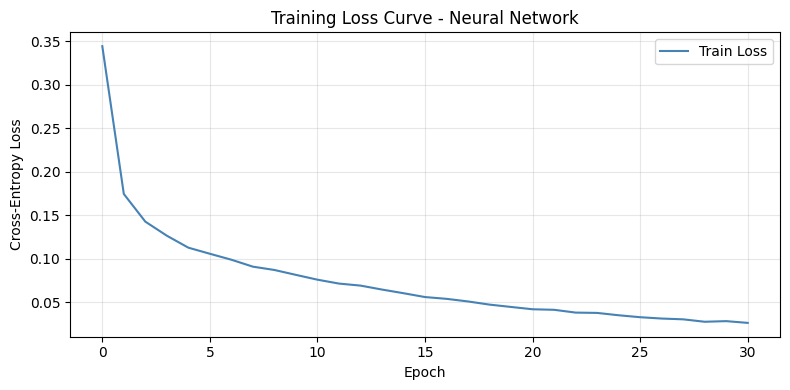

In [79]:
plt.figure(figsize=(8, 4))
plt.plot(model_nn.loss_curve_, color='steelblue', label='Train Loss')
plt.title("Training Loss Curve - Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluation Helper Functions

In [80]:
def model_performance_nn(model, X, y_true, dataset_name=""):
    """Return accuracy, recall, precision, F1, ROC-AUC as a DataFrame."""
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    result = pd.DataFrame({
        "Accuracy":  [round(accuracy_score(y_true, preds),  4)],
        "Recall":    [round(recall_score(y_true, preds),    4)],
        "Precision": [round(precision_score(y_true, preds), 4)],
        "F1":        [round(f1_score(y_true, preds),        4)],
        "ROC-AUC":   [round(roc_auc_score(y_true, probs),  4)],
    })
    print(f"\n{'='*55}")
    print(f"  Neural Network Performance — {dataset_name}")
    print(f"{'='*55}")
    print(result.to_string(index=False))
    return result, probs


def plot_confusion_matrix(model, X, y_true, title):
    """Plot confusion matrix with counts and row percentages."""
    preds = model.predict(X)
    cm = confusion_matrix(y_true, preds)
    labels = np.asarray(
        [[f"{v}\n({v/cm.sum():.1%})" for v in row] for row in cm]
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
                xticklabels=["Existing (0)", "Attrited (1)"],
                yticklabels=["Existing (0)", "Attrited (1)"])
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

### Performance on Train / Validation / Test Sets

In [81]:
nn_train, _          = model_performance_nn(model_nn, X_train_sc, y_train_res, "Training Set (SMOTE)")
nn_val,   val_probs  = model_performance_nn(model_nn, X_val_sc,   y_val,       "Validation Set")
nn_test,  test_probs = model_performance_nn(model_nn, X_test_sc,  y_test,      "Test Set")


  Neural Network Performance — Training Set (SMOTE)
 Accuracy  Recall  Precision    F1  ROC-AUC
    0.978   0.985      0.972 0.978    0.998

  Neural Network Performance — Validation Set
 Accuracy  Recall  Precision    F1  ROC-AUC
    0.917   0.763      0.745 0.754    0.952

  Neural Network Performance — Test Set
 Accuracy  Recall  Precision    F1  ROC-AUC
    0.923   0.784      0.716 0.748    0.963


### Confusion Matrices

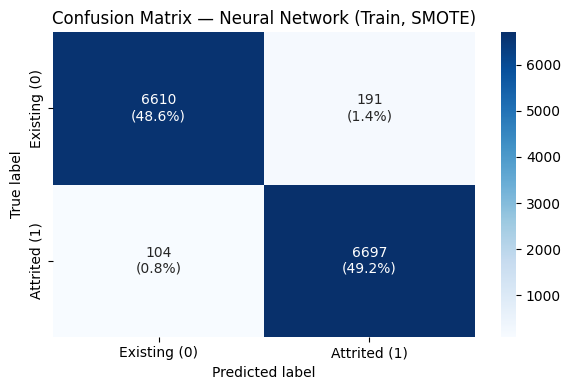

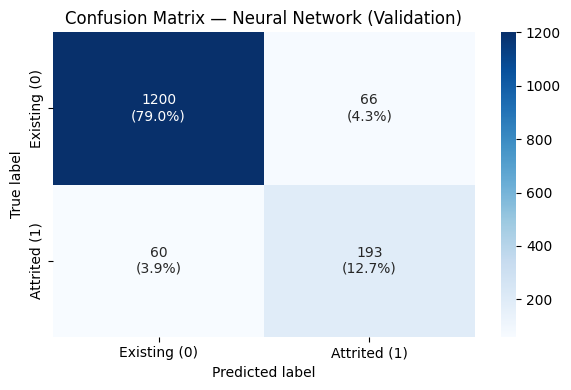

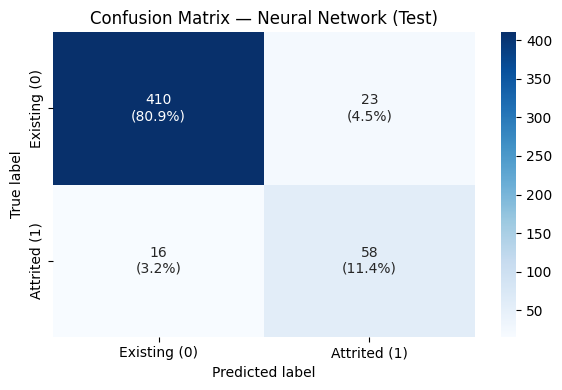

In [82]:
plot_confusion_matrix(model_nn, X_train_sc, y_train_res,
                      "Confusion Matrix — Neural Network (Train, SMOTE)")
plot_confusion_matrix(model_nn, X_val_sc,   y_val,
                      "Confusion Matrix — Neural Network (Validation)")
plot_confusion_matrix(model_nn, X_test_sc,  y_test,
                      "Confusion Matrix — Neural Network (Test)")

### ROC Curve

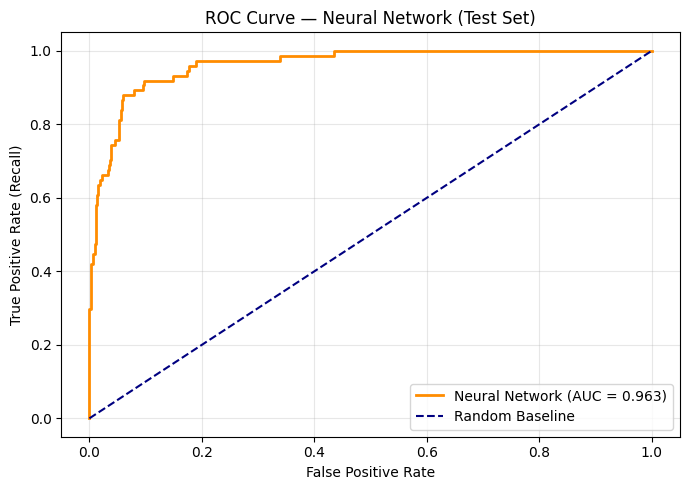

In [83]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc_score  = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"Neural Network (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Neural Network (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Building Model Random Forest

In [84]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=1
)
model_rf.fit(X_train_sc, y_train_res)
print("Random Forest trained.")

Random Forest trained.


In [85]:
def model_performance_generic(model, X, y_true, model_name, dataset_name=""):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    result = pd.DataFrame({
        "Accuracy":  [round(accuracy_score(y_true, preds),  4)],
        "Recall":    [round(recall_score(y_true, preds),    4)],
        "Precision": [round(precision_score(y_true, preds), 4)],
        "F1":        [round(f1_score(y_true, preds),        4)],
        "ROC-AUC":   [round(roc_auc_score(y_true, probs),  4)],
    })
    print(f"\n{'='*55}\n  {model_name} — {dataset_name}\n{'='*55}")
    print(result.to_string(index=False))
    return result, probs

rf_train, _         = model_performance_generic(model_rf, X_train_sc, y_train_res, "Random Forest", "Training (SMOTE)")
rf_val,   rf_val_p  = model_performance_generic(model_rf, X_val_sc,   y_val,       "Random Forest", "Validation")
rf_test,  rf_test_p = model_performance_generic(model_rf, X_test_sc,  y_test,      "Random Forest", "Test")


  Random Forest — Training (SMOTE)
 Accuracy  Recall  Precision    F1  ROC-AUC
    1.000   1.000      1.000 1.000    1.000

  Random Forest — Validation
 Accuracy  Recall  Precision    F1  ROC-AUC
    0.960   0.877      0.881 0.879    0.988

  Random Forest — Test
 Accuracy  Recall  Precision    F1  ROC-AUC
    0.961   0.865      0.865 0.865    0.989


# Model Compare

In [86]:
comparison = pd.DataFrame({
    "Model":     ["Neural Network (MLP)", "Random Forest"],
    "Accuracy":  [nn_test["Accuracy"].iloc[0],  rf_test["Accuracy"].iloc[0]],
    "Recall":    [nn_test["Recall"].iloc[0],    rf_test["Recall"].iloc[0]],
    "Precision": [nn_test["Precision"].iloc[0], rf_test["Precision"].iloc[0]],
    "F1":        [nn_test["F1"].iloc[0],        rf_test["F1"].iloc[0]],
    "ROC-AUC":   [nn_test["ROC-AUC"].iloc[0],   rf_test["ROC-AUC"].iloc[0]],
})
print("\n===== Test Set Comparison =====")
print(comparison.to_string(index=False))


===== Test Set Comparison =====
               Model  Accuracy  Recall  Precision    F1  ROC-AUC
Neural Network (MLP)     0.923   0.784      0.716 0.748    0.963
       Random Forest     0.961   0.865      0.865 0.865    0.989


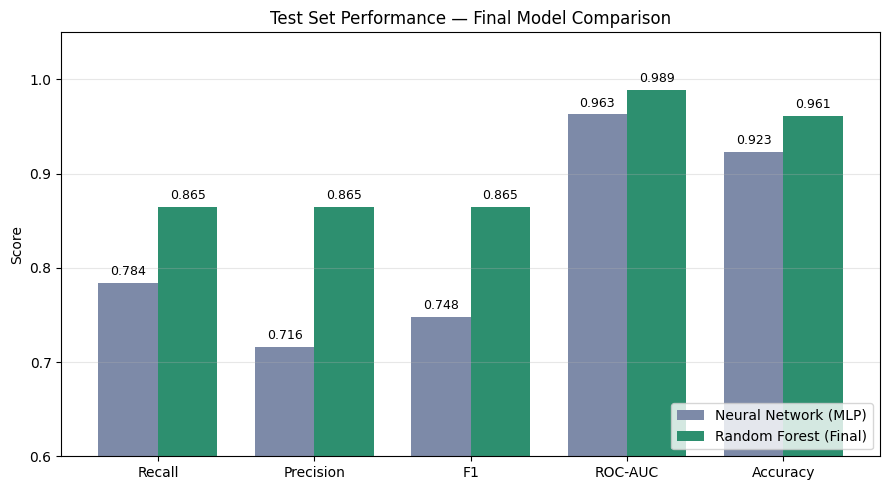

Saved: model_comparison.png — 直接插到 memo 里


In [88]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Recall", "Precision", "F1", "ROC-AUC", "Accuracy"]
nn_vals = [0.784, 0.716, 0.748, 0.963, 0.923]
rf_vals = [0.865, 0.865, 0.865, 0.989, 0.961]

x = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, nn_vals, width, label="Neural Network (MLP)", color="#7D8AA8")
bars2 = ax.bar(x + width/2, rf_vals, width, label="Random Forest (Final)", color="#2D8F6F")

# Label values on top
for bars in [bars1, bars2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Test Set Performance — Final Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.6, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png — 直接插到 memo 里")

# saving for AWS

In [87]:
import joblib, os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(model_rf, "artifacts/rf_model.pkl")
joblib.dump(scaler,   "artifacts/scaler.pkl")
joblib.dump(list(X_train_res.columns), "artifacts/feature_columns.pkl")
print("Saved: artifacts/rf_model.pkl, scaler.pkl, feature_columns.pkl")

Saved: artifacts/rf_model.pkl, scaler.pkl, feature_columns.pkl


In [89]:
import sklearn; print(sklearn.__version__)

1.7.2
